# SECTION 1
Importing all required libraries

In [141]:
pip install pandas numpy matplotlib seaborn scikit-learn missingno 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
import missingno as msno
import math
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GRU
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# SECTION 2
Importing all the required datasets

In [100]:
aman_df1=pd.read_csv(r"C:\Users\Aman Kumar\Downloads\gas+turbine+co+and+nox+emission+data+set_\gt_2011_.csv")
aman_df2=pd.read_csv(r"C:\Users\Aman Kumar\Downloads\gas+turbine+co+and+nox+emission+data+set_\gt_2012_.csv")
aman_df3=pd.read_csv(r"C:\Users\Aman Kumar\Downloads\gas+turbine+co+and+nox+emission+data+set_\gt-2013_.csv")
aman_df4=pd.read_csv(r"C:\Users\Aman Kumar\Downloads\gas+turbine+co+and+nox+emission+data+set_\gt_2014_.csv")
aman_df5=pd.read_csv(r"C:\Users\Aman Kumar\Downloads\gas+turbine+co+and+nox+emission+data+set_\gt_2015_.csv")

In [101]:
aman_df1.head()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,12.558310,0.32663,81.952
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.981920,0.44784,82.377
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.711840,0.45144,83.776
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,13.503730,0.23107,82.505
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.894879,0.26747,82.028


# SECTION 3
* Visualizing the data distribution of individual datasets
* Transforming features into log-transform
* Plotting multi-line time series plot of all the datasets
* Combining all the 4 datasets into single dataset
* Visualizing the data distribution of combined dataset

  ***Correlation Heatmap***
 * Drop the columns based on the heat map if required 

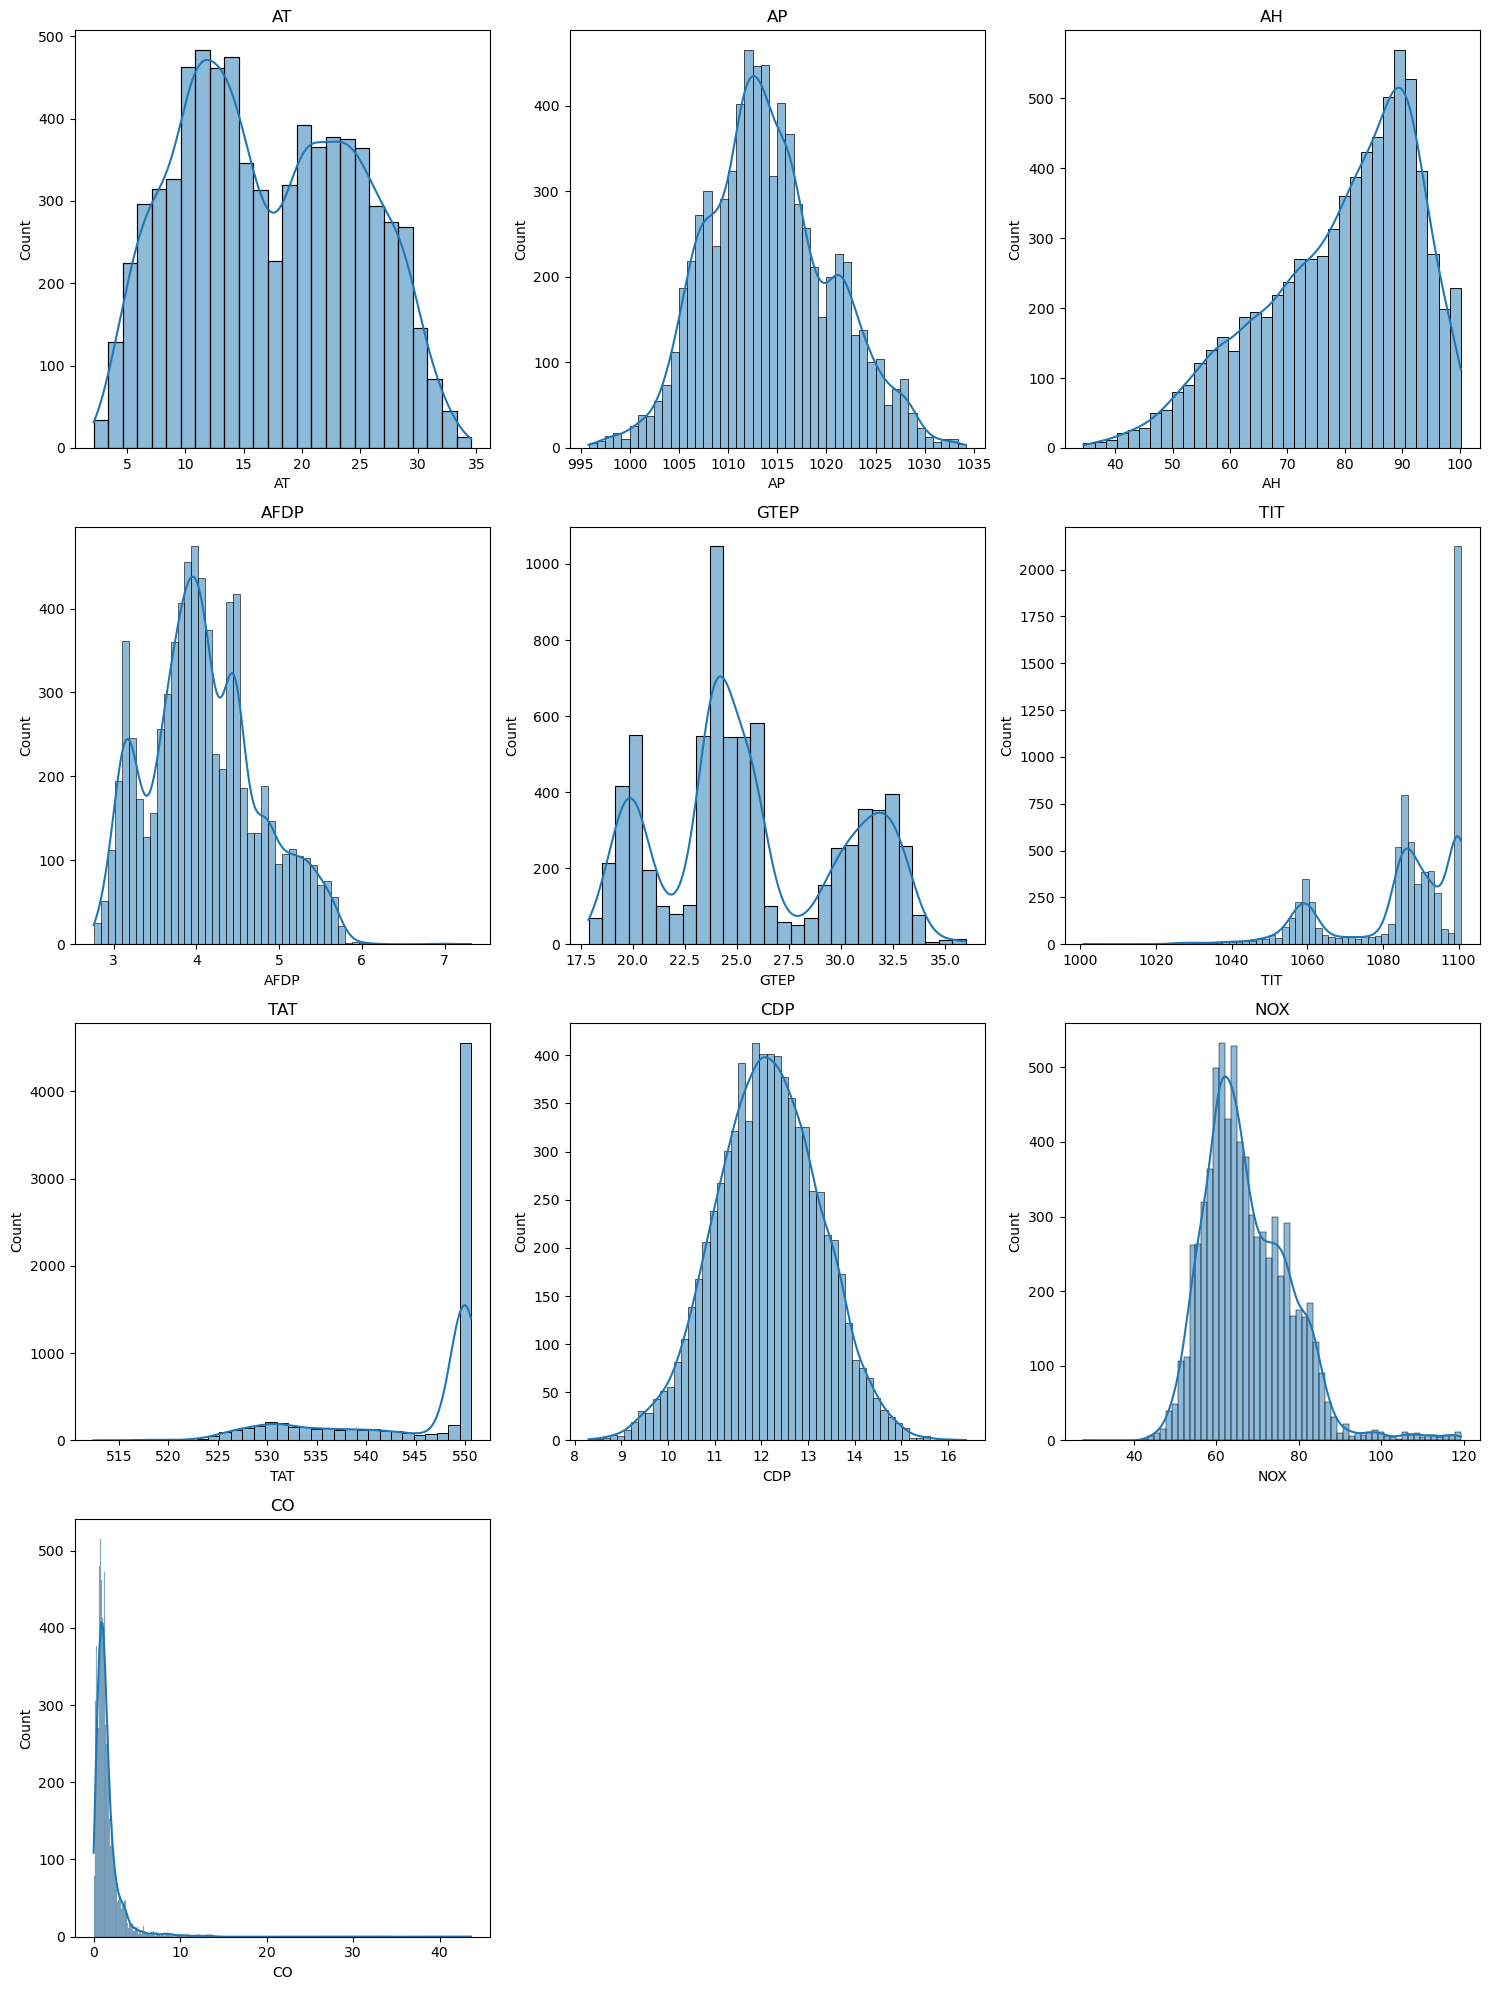

In [102]:
warnings.filterwarnings("ignore")

cols = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "CDP", "NOX", "CO"]

n_cols = 3 
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(aman_df1[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

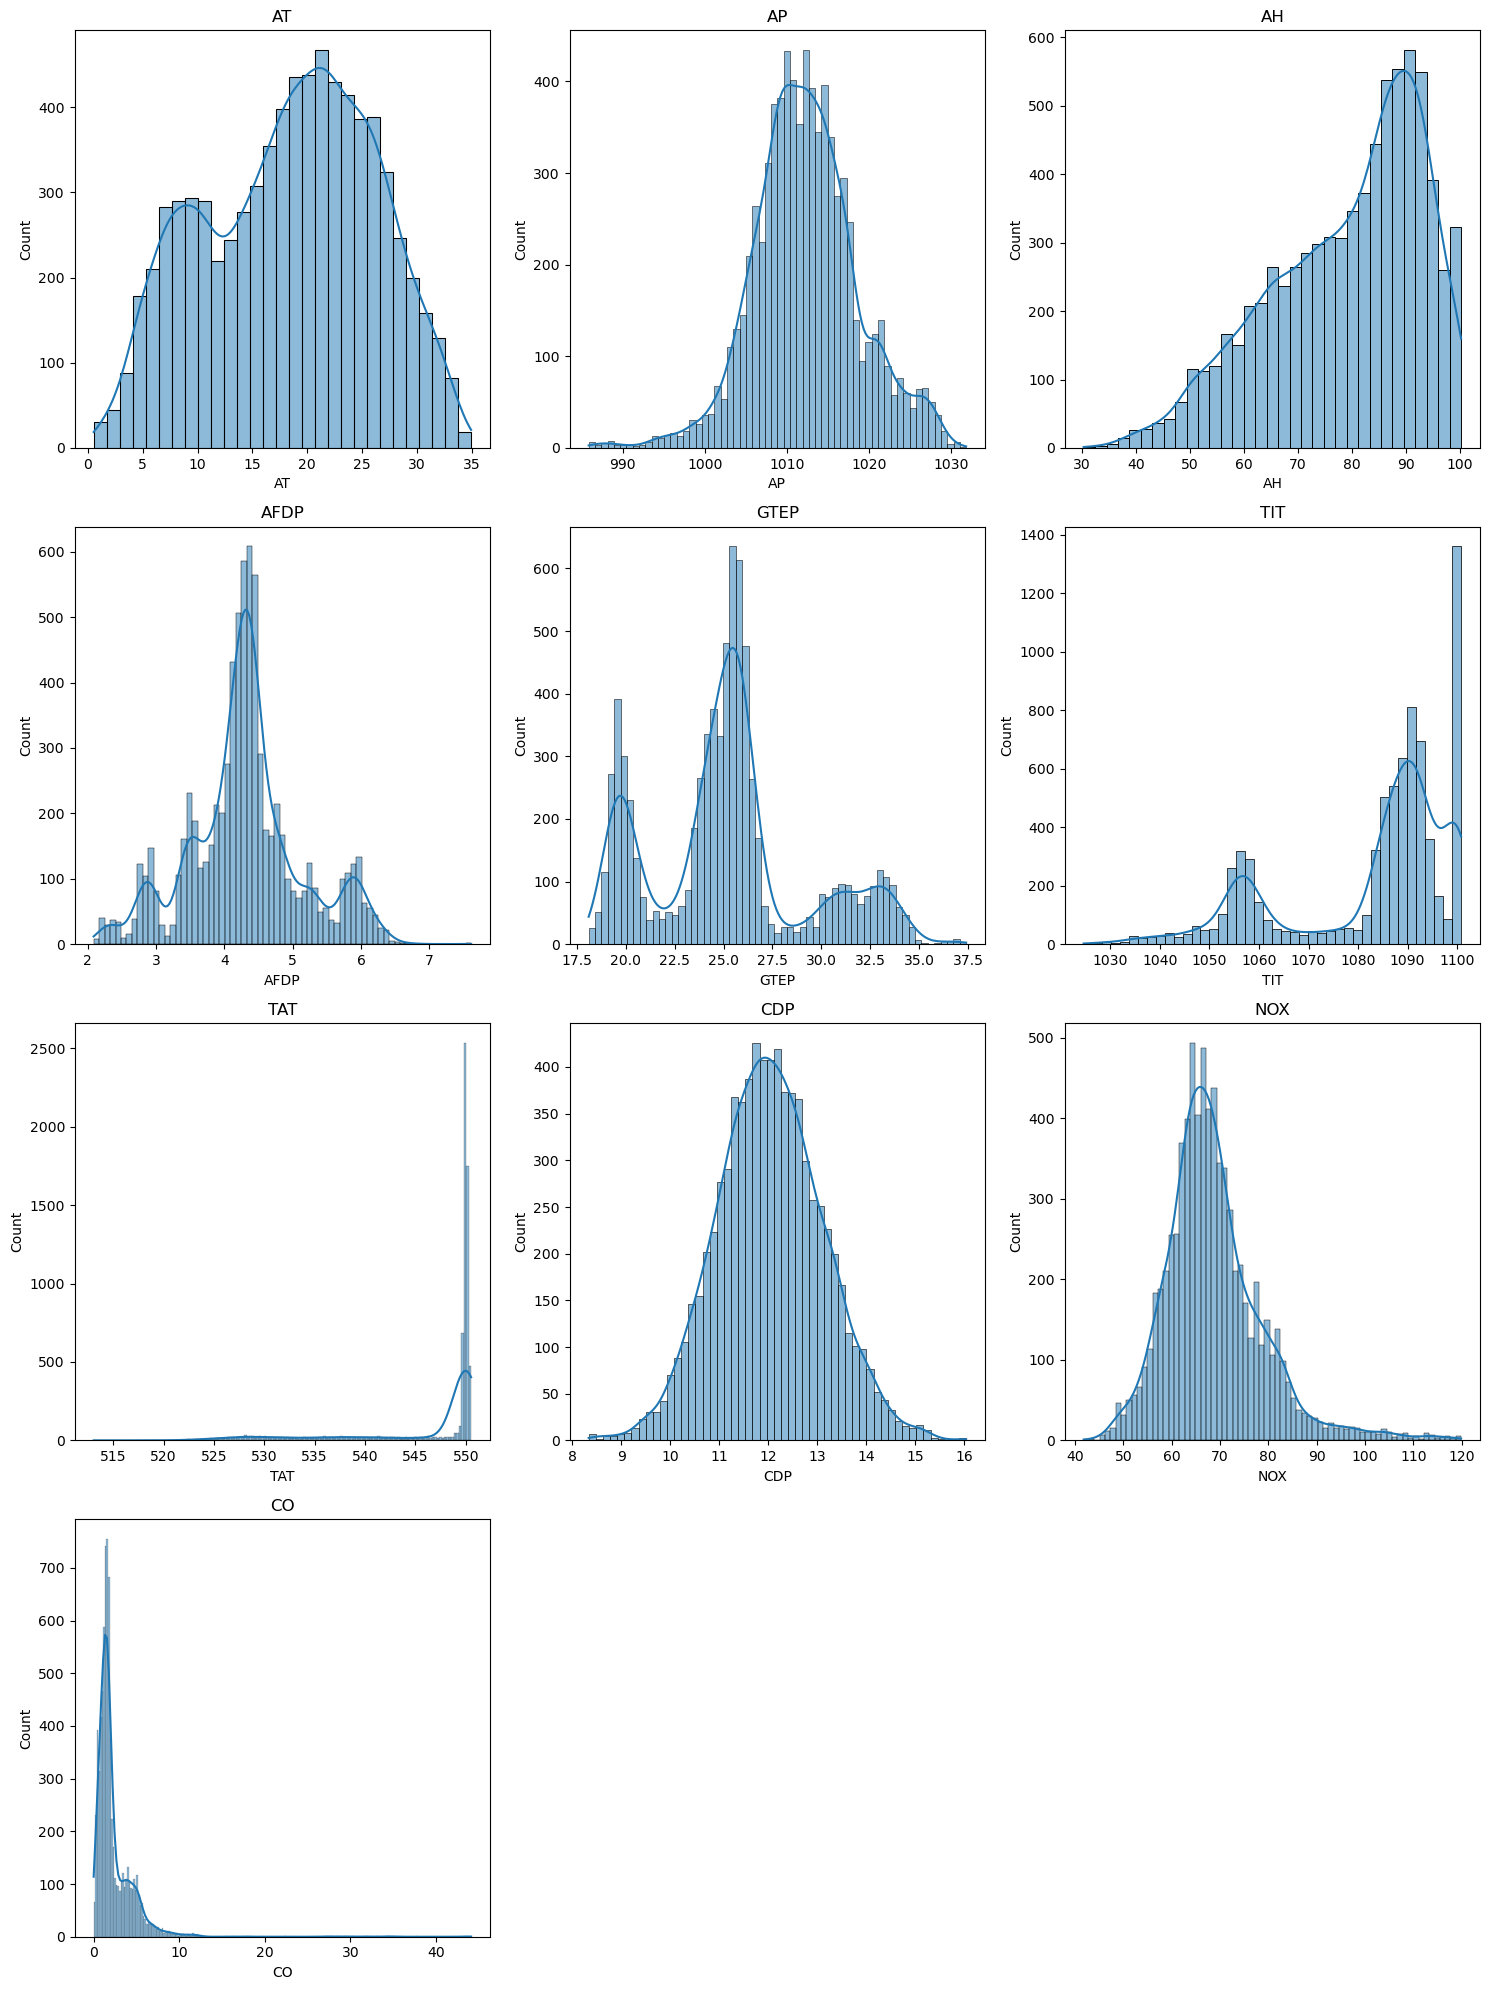

In [103]:
warnings.filterwarnings("ignore")

cols = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "CDP", "NOX", "CO"]

n_cols = 3 
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(aman_df2[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

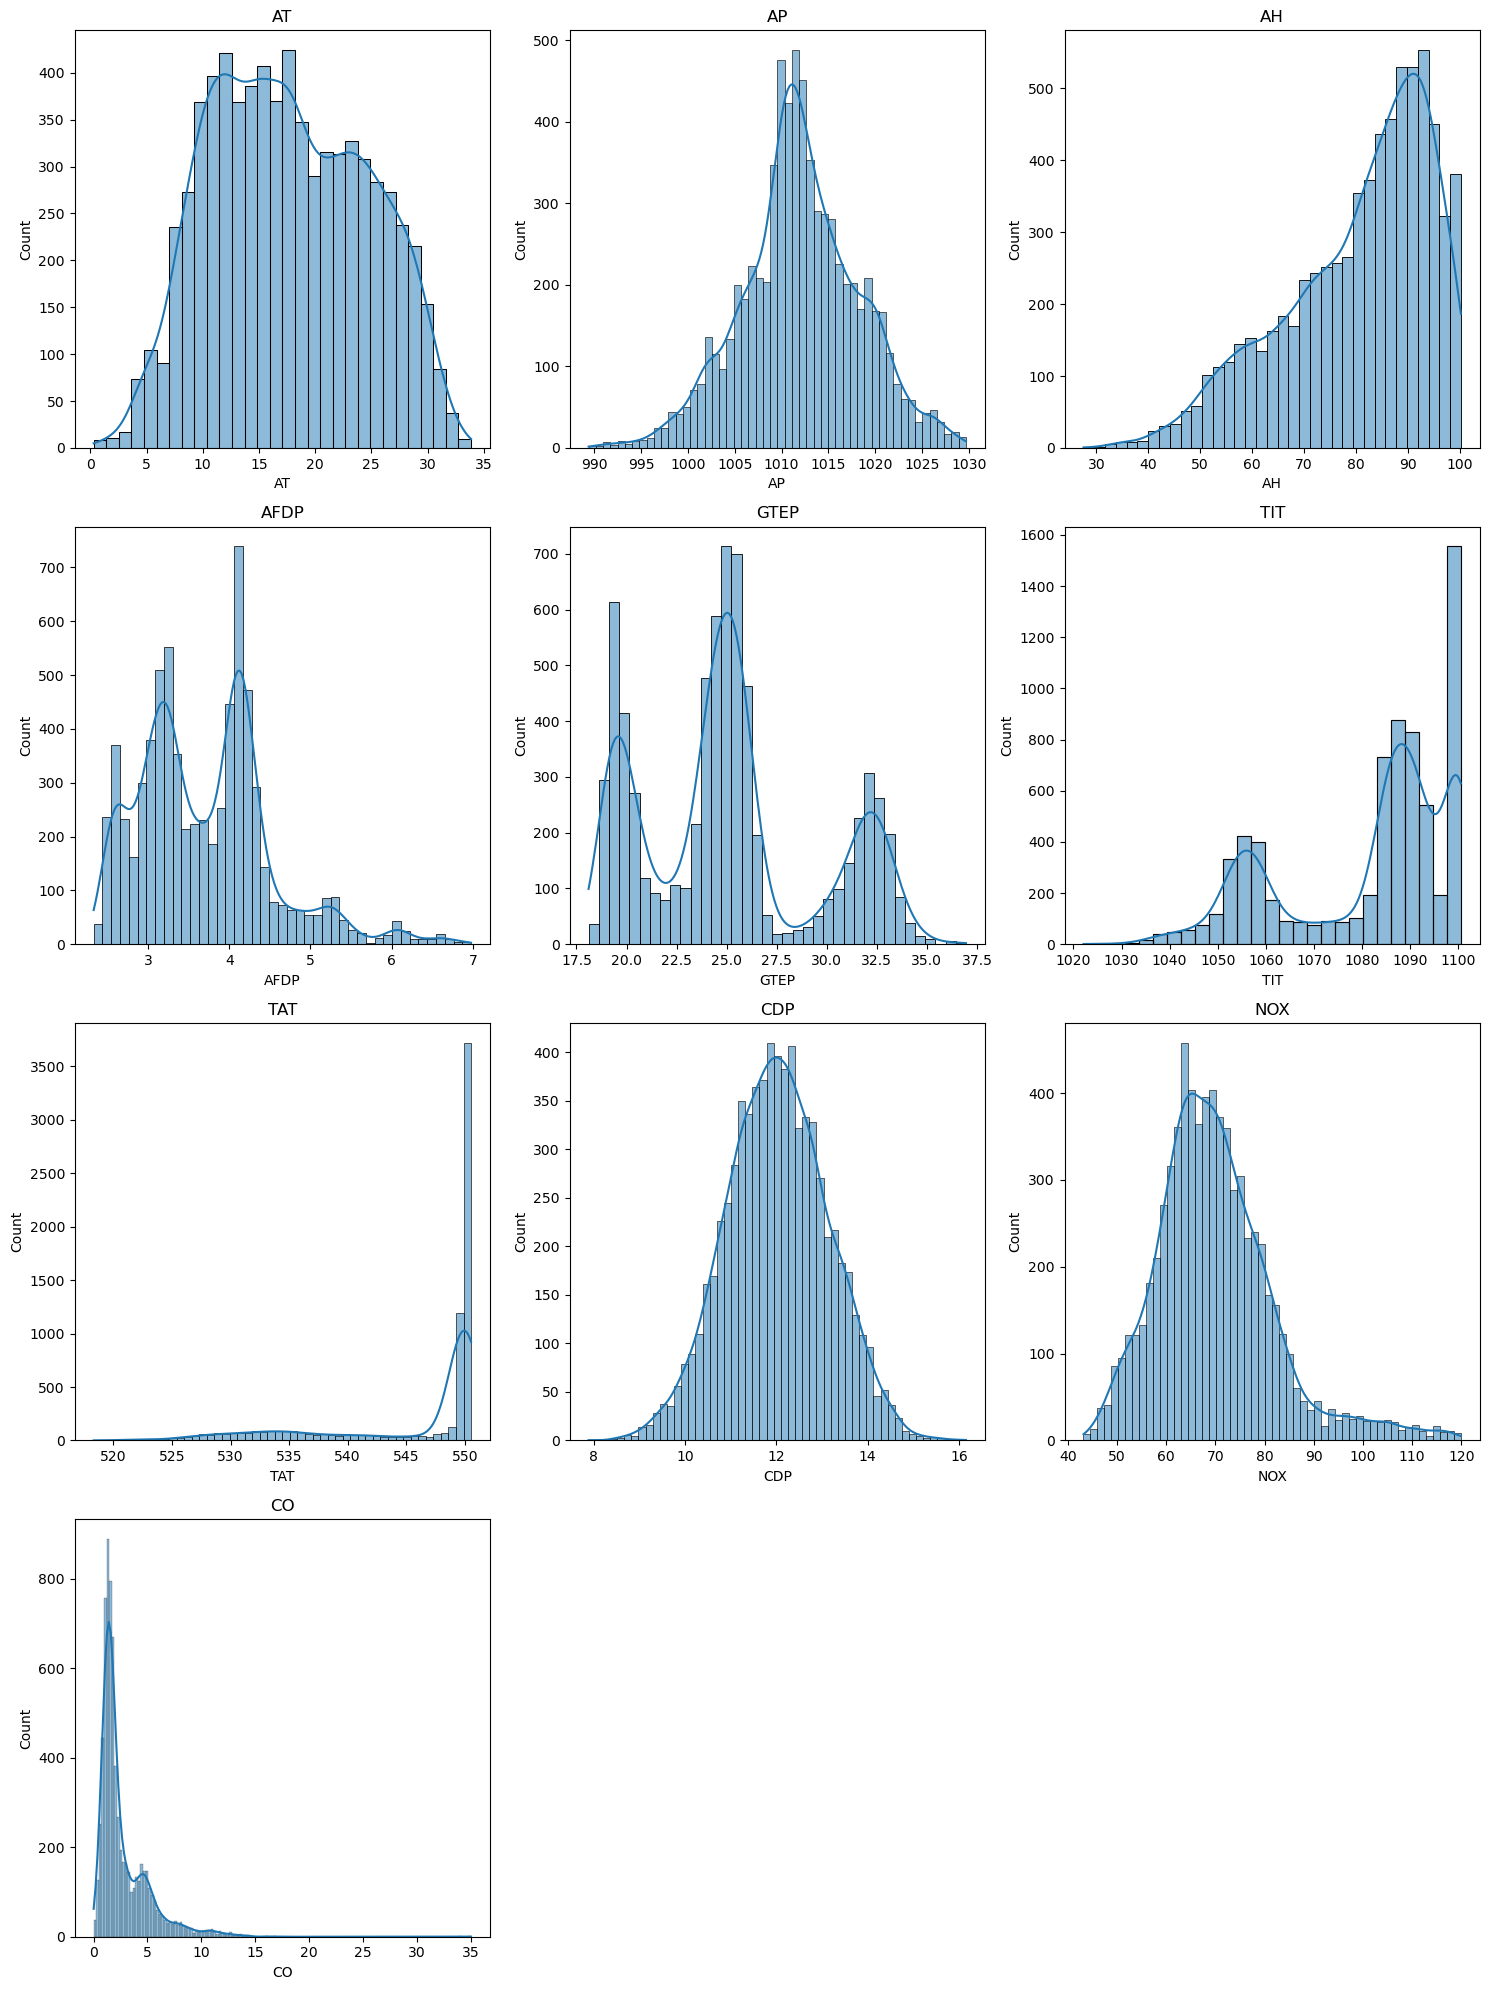

In [104]:
warnings.filterwarnings("ignore")

cols = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "CDP", "NOX", "CO"]

n_cols = 3 
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(aman_df3[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

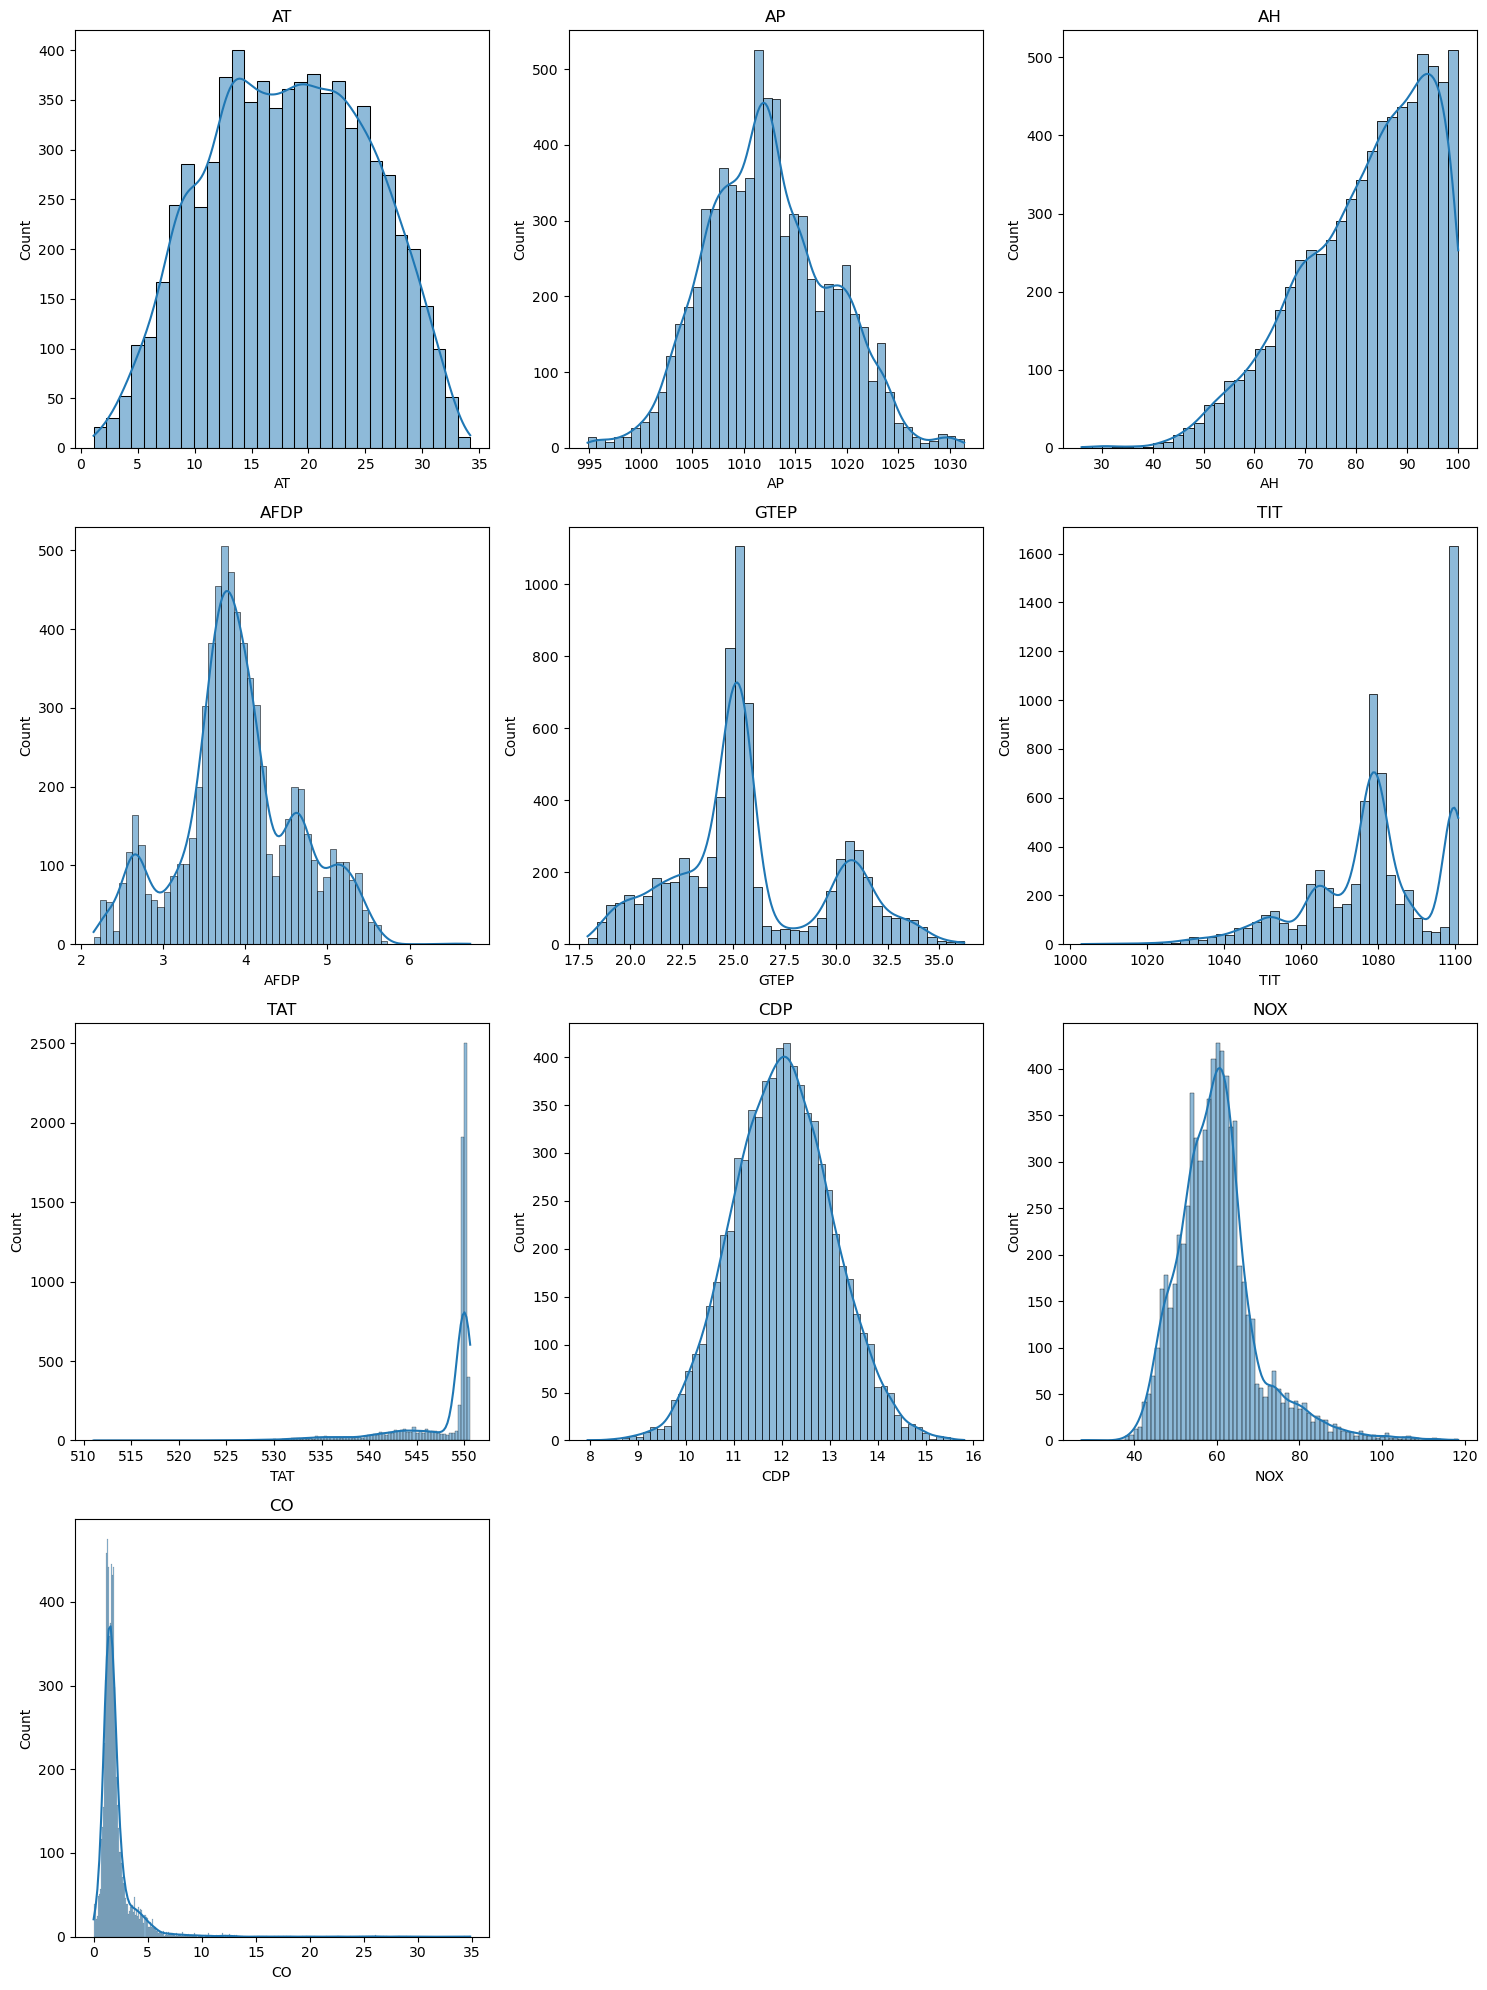

In [105]:
warnings.filterwarnings("ignore")

cols = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "CDP", "NOX", "CO"]

n_cols = 3  
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(aman_df4[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

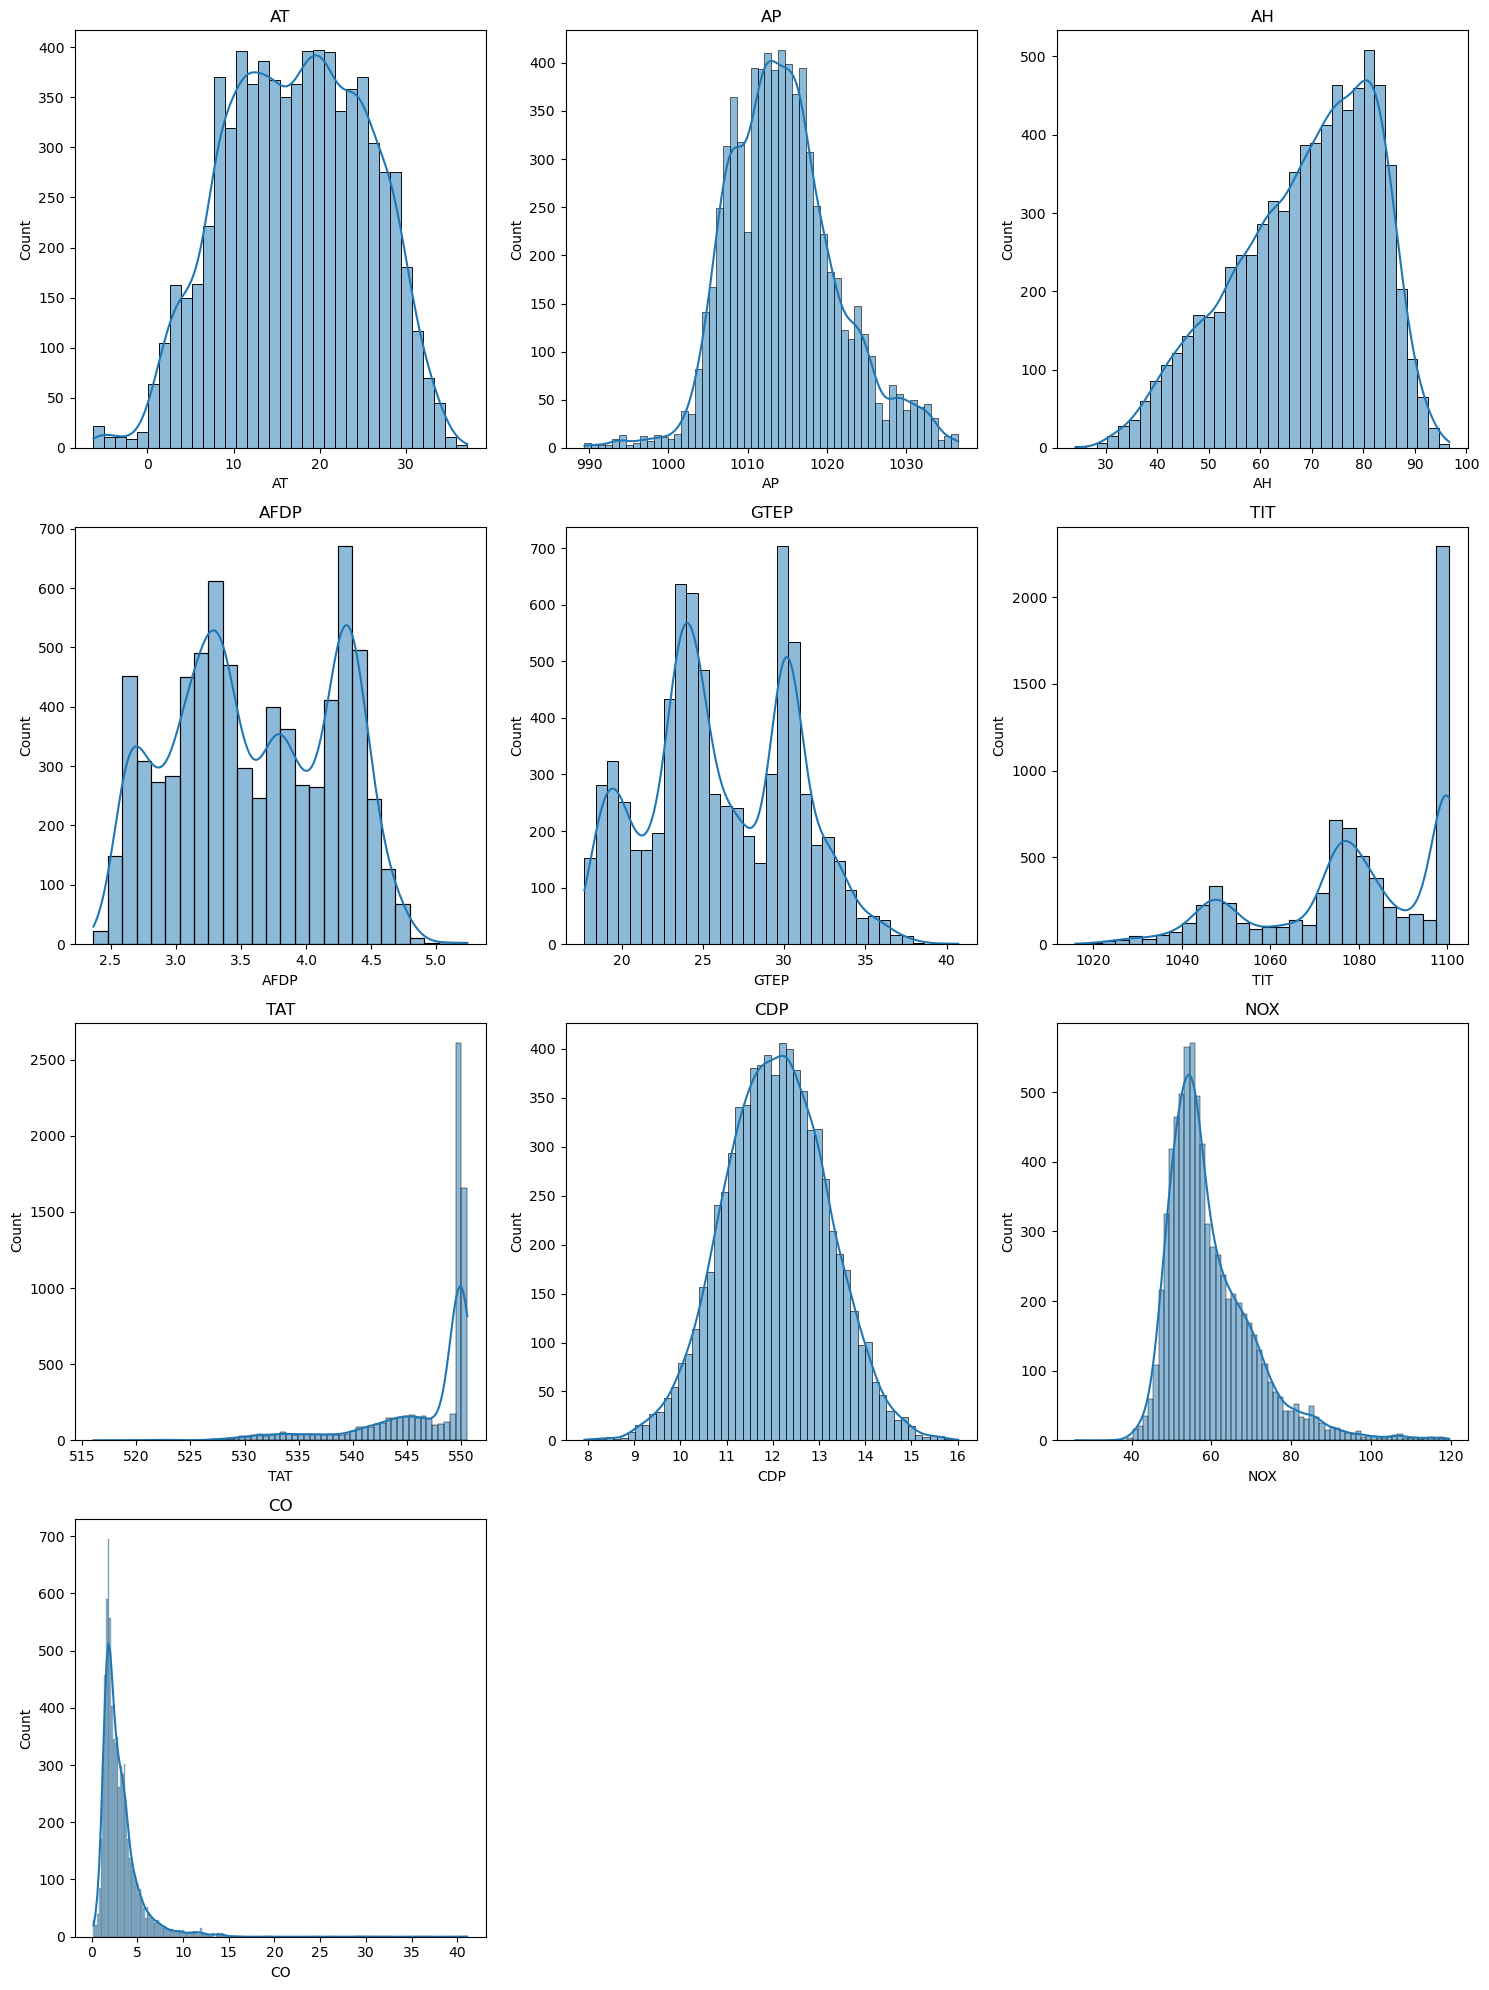

In [106]:
warnings.filterwarnings("ignore")

cols = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "CDP", "NOX", "CO"]

n_cols = 3  
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(aman_df5[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [107]:
aman_df1["CO"] = np.log(aman_df1["CO"])
aman_df2["CO"] = np.log(aman_df2["CO"])
aman_df3["CO"] = np.log(aman_df3["CO"])
aman_df4["CO"] = np.log(aman_df4["CO"])
aman_df5["CO"] = np.log(aman_df5["CO"])

<Axes: >

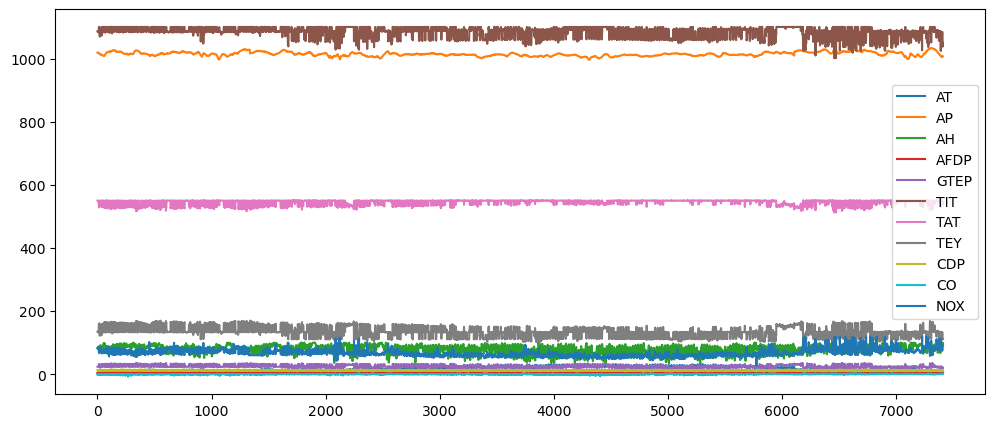

In [108]:
aman_df1.plot(figsize=(12,5))

<Axes: >

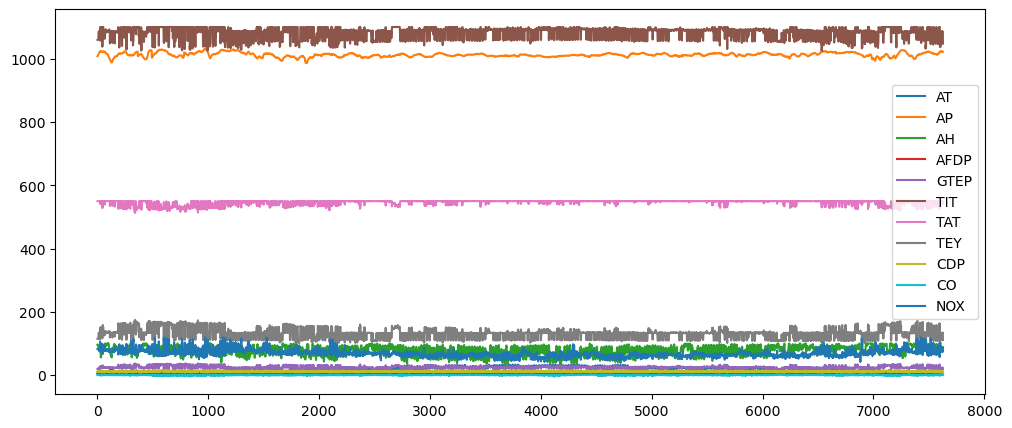

In [109]:
aman_df2.plot(figsize=(12,5))

<Axes: >

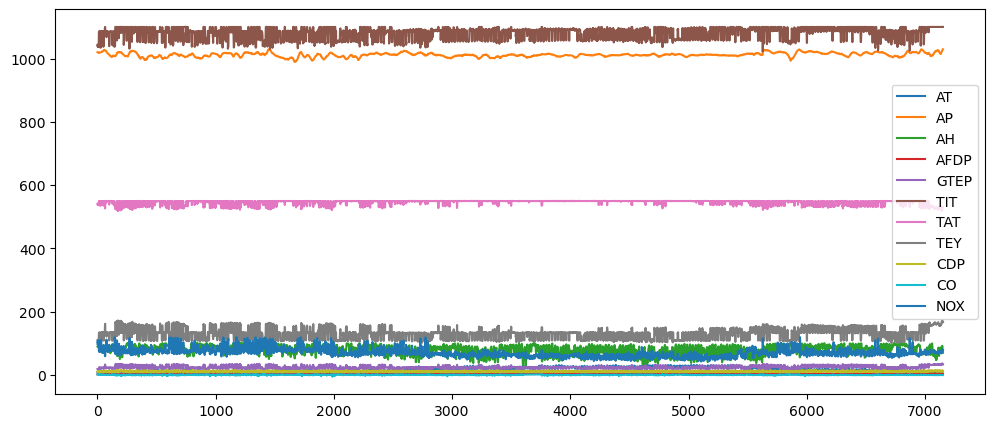

In [110]:
aman_df3.plot(figsize=(12,5))

<Axes: >

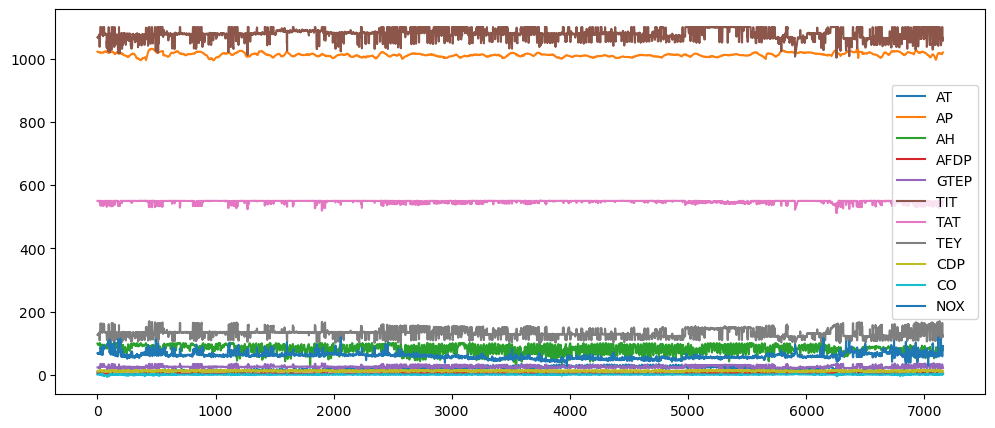

In [111]:
aman_df4.plot(figsize=(12,5))

<Axes: >

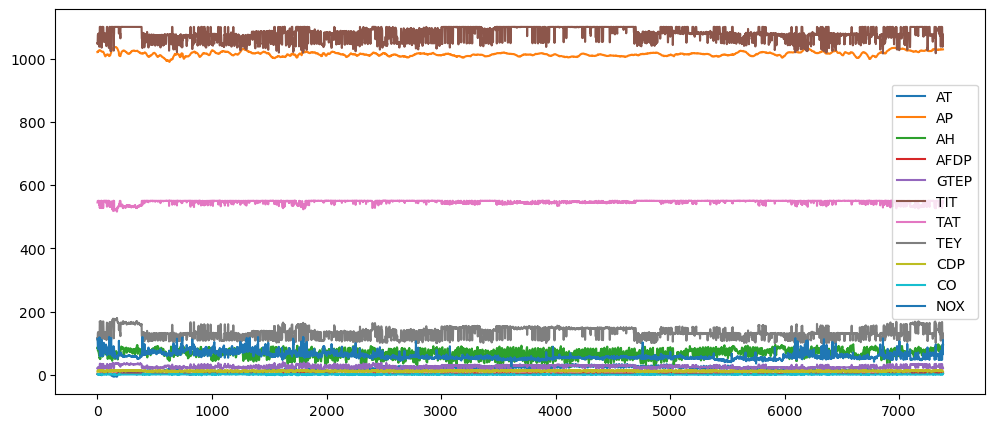

In [112]:
aman_df5.plot(figsize=(12,5))

In [113]:
aman_df = pd.concat([aman_df1, aman_df2, aman_df3, aman_df4, aman_df5])

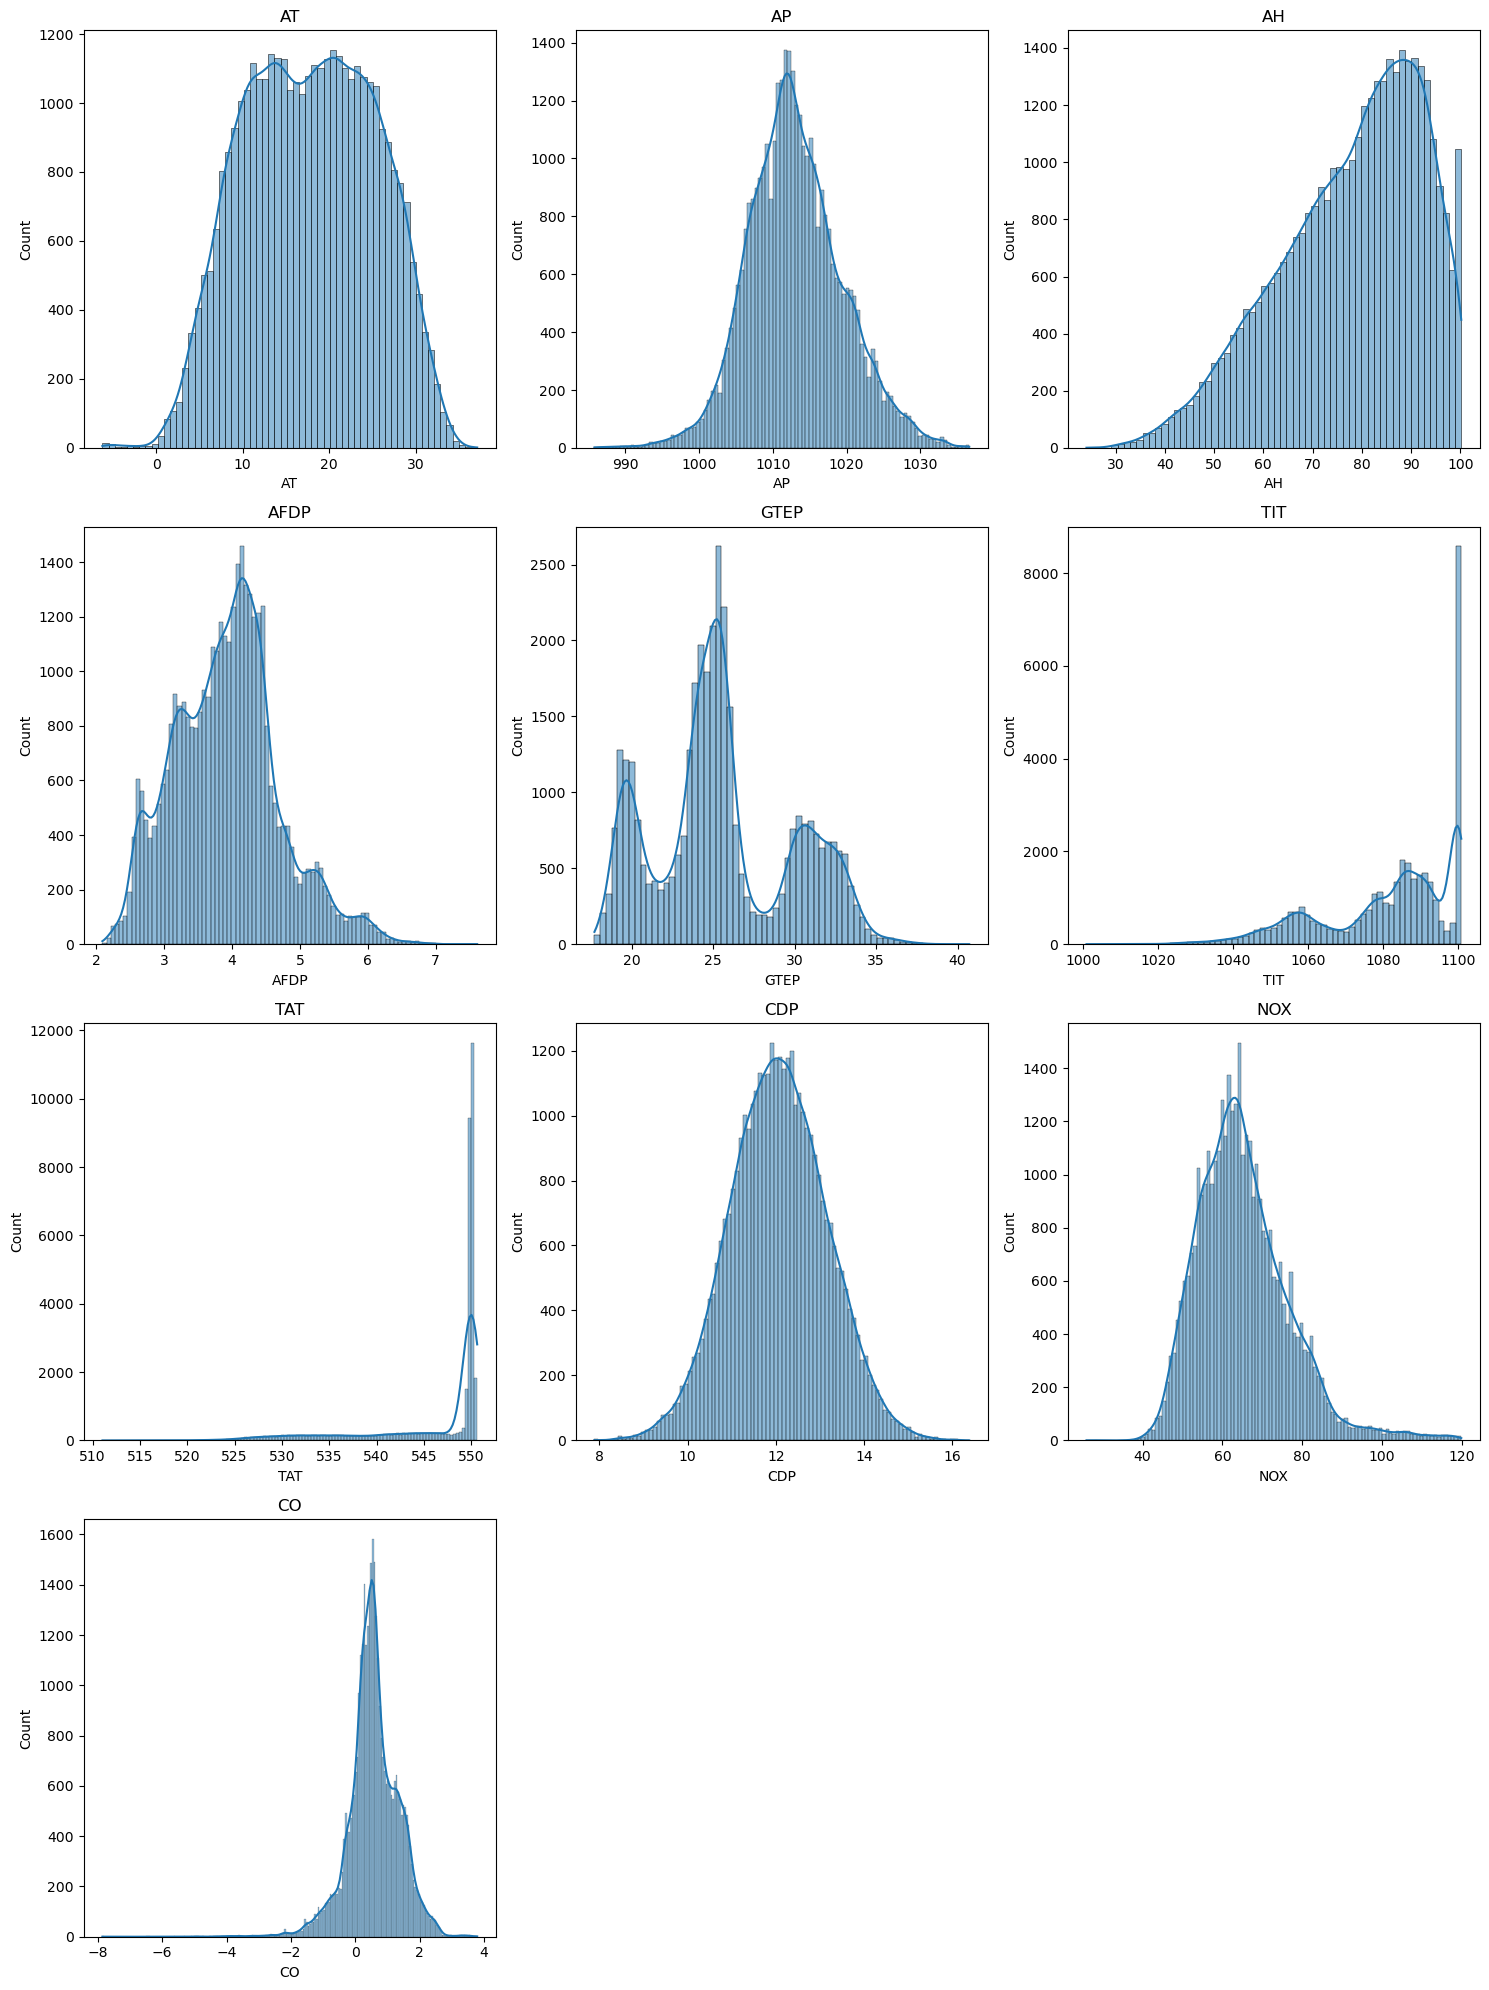

In [114]:
warnings.filterwarnings("ignore")

cols = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "CDP", "NOX", "CO"]

n_cols = 3 
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(aman_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: >

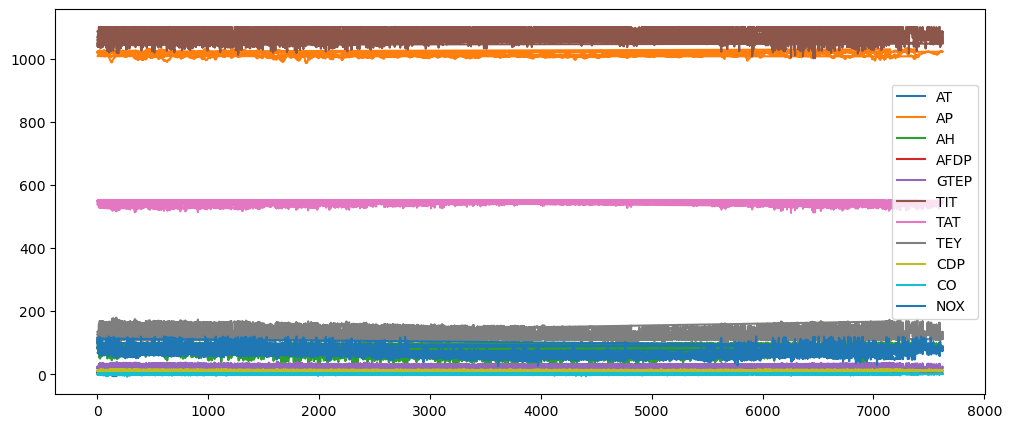

In [115]:
aman_df.plot(figsize=(12,5))

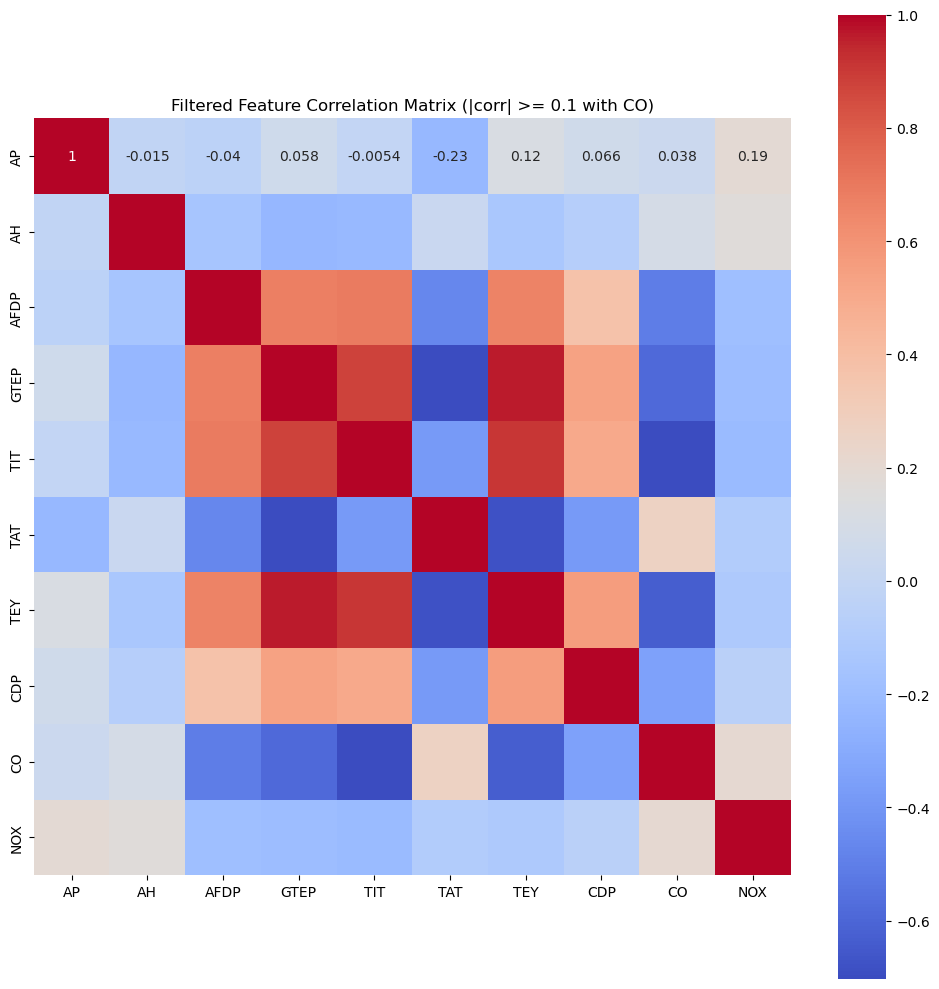

In [116]:
numerical_cols = aman_df.select_dtypes(include=['int64', 'float64']).columns
aman_df_numerical=aman_df[numerical_cols]

corr = aman_df_numerical.corr()

target_corr = corr['TEY'].abs()

selected_cols = target_corr[target_corr >= 0.1].index

aman_df_filtered = aman_df_numerical[selected_cols]

plt.figure(figsize=(10,10))
sns.heatmap(aman_df_filtered.corr(), annot=True, cmap='coolwarm', square=True)
plt.title('Filtered Feature Correlation Matrix (|corr| >= 0.1 with CO)')
plt.tight_layout()

In [117]:
aman_df=aman_df.drop(columns=["GTEP", "TIT"], axis=1)

In [118]:
aman_df.shape

(36733, 9)

In [119]:
aman_df.head()

,AT,AP,AH,AFDP,TAT,TEY,CDP,CO,NOX
0,4.5878,1018.7,83.675,3.5758,549.83,134.67,12.558310,-1.118927,81.952
1,4.2932,1018.3,84.235,3.5709,550.05,134.67,11.981920,-0.803319,82.377
2,3.9045,1018.4,84.858,3.5828,550.19,135.10,12.711840,-0.795313,83.776
3,3.7436,1018.3,85.434,3.5808,550.17,135.03,13.503730,-1.465035,82.505
4,3.7516,1017.8,85.182,3.5781,550.00,134.67,11.894879,-1.318748,82.028


# SECTION 4: (Regression using Simple Linear Regression + Time-Based Cross-Validation and Min-Max Scaling)


* Calculate the mean-squared error and R2 value for all.
* Simple Linear Regression + Time-Based Cross-Validation and Min-Max Scaling
* PCA + Simple Linear Regression + Time-Based Cross-Validation and Min-Max Scaling
* Lasso Regression + Time-Based Cross-Validation and Min-Max Scaling
* Ridge Regression + Time-Based Cross-Validation and Min-Max Scaling

In [120]:
X = aman_df.drop("TEY", axis=1).values
y = aman_df["TEY"].values   # ← keep 1D

tscv = TimeSeriesSplit(n_splits=10)

mse_list, r2_list = [], []

for fold, (train_index, test_index) in enumerate(tscv.split(X), 1):

    print(f"\nFold {fold}")

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scaling only X
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", mse)
    print("R²:", r2)

    mse_list.append(mse)
    r2_list.append(r2)

print("\n===== Final Results =====")
print("Average MSE:", np.mean(mse_list))
print("Average R²:", np.mean(r2_list))


Fold 1
MSE: 50.8064746151882
R²: 0.787498313342079

Fold 2
MSE: 132.76602428554324
R²: 0.5863861545631116

Fold 3
MSE: 45.21846454944074
R²: 0.6134654899938192

Fold 4
MSE: 168.32178652575132
R²: 0.43934732469350124

Fold 5
MSE: 47.55386246948174
R²: 0.7454820129919351

Fold 6
MSE: 64.62771619383014
R²: 0.7341482390866374

Fold 7
MSE: 41.371362506851135
R²: 0.6624688344316503

Fold 8
MSE: 76.7511455435965
R²: 0.7538317070735919

Fold 9
MSE: 86.33127525088497
R²: 0.6595446204754758

Fold 10
MSE: 54.55105574548306
R²: 0.7486145893715638

===== Final Results =====
Average MSE: 76.8299167686051
Average R²: 0.6730787286023365


In [121]:
X = aman_df.drop("TEY", axis=1).select_dtypes(include=['int64', 'float64']).values
y = aman_df["TEY"].values

tscv = TimeSeriesSplit(n_splits=10)

mse_list, r2_list = [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):

    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=0.95)   
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    print("Explained Variance:", pca.explained_variance_ratio_)

    model = LinearRegression()
    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", mse)
    print("R²:", r2)

    mse_list.append(mse)
    r2_list.append(r2)
print("\n===== FINAL RESULTS =====")
print("Average MSE:", np.mean(mse_list))
print("Average R²:", np.mean(r2_list))
print("Std MSE:", np.std(mse_list))
print("Std R²:", np.std(r2_list))


===== Fold 1 =====
Explained Variance: [0.33410833 0.23642106 0.13463966 0.09389564 0.08056551 0.07380675]
MSE: 45.1051644021017
R²: 0.8113444480250537

===== Fold 2 =====
Explained Variance: [0.32708359 0.2808933  0.12335205 0.08796042 0.07504748 0.06460164]
MSE: 100.03321675984905
R²: 0.6883606052217363

===== Fold 3 =====
Explained Variance: [0.30745348 0.28176822 0.12189358 0.0922744  0.07569003 0.06836918
 0.03329083]
MSE: 42.44511515484148
R²: 0.6371725145467045

===== Fold 4 =====
Explained Variance: [0.31416855 0.26099183 0.12164907 0.09292564 0.07990432 0.07524152
 0.03786709]
MSE: 169.1896618300193
R²: 0.4364565722768743

===== Fold 5 =====
Explained Variance: [0.29870757 0.26985815 0.12024198 0.09071673 0.07989737 0.0689849
 0.05352436]
MSE: 47.906484134125066
R²: 0.7435947098035126

===== Fold 6 =====
Explained Variance: [0.29747678 0.27163165 0.11900102 0.09239222 0.07944605 0.06984364
 0.05241089]
MSE: 65.80999854803447
R²: 0.729284817256608

===== Fold 7 =====
Explained

In [122]:
feature_names = aman_df.drop("TEY", axis=1)\
                       .select_dtypes(include=['int64', 'float64'])\
                       .columns
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

print(loadings)

           PC1       PC2       PC3       PC4       PC5       PC6       PC7
AT    0.328926 -0.538176  0.131336  0.001543  0.043079 -0.078517  0.263572
AP   -0.079453  0.400096  0.532658 -0.670624 -0.104786 -0.044414  0.254707
AH   -0.278802  0.207815 -0.780942 -0.293582  0.040182 -0.116438  0.254808
AFDP  0.520015  0.156483 -0.084063  0.046210  0.447714 -0.039121  0.602992
TAT  -0.281868 -0.477987 -0.036595 -0.143492 -0.371201  0.439785  0.479384
CDP   0.357388  0.310574 -0.088988  0.285743 -0.788515 -0.173147  0.179588
CO   -0.461174 -0.144151  0.190718  0.250270  0.028182 -0.749901  0.297466
NOX  -0.342771  0.370011  0.190942  0.545033  0.157357  0.437071  0.294245


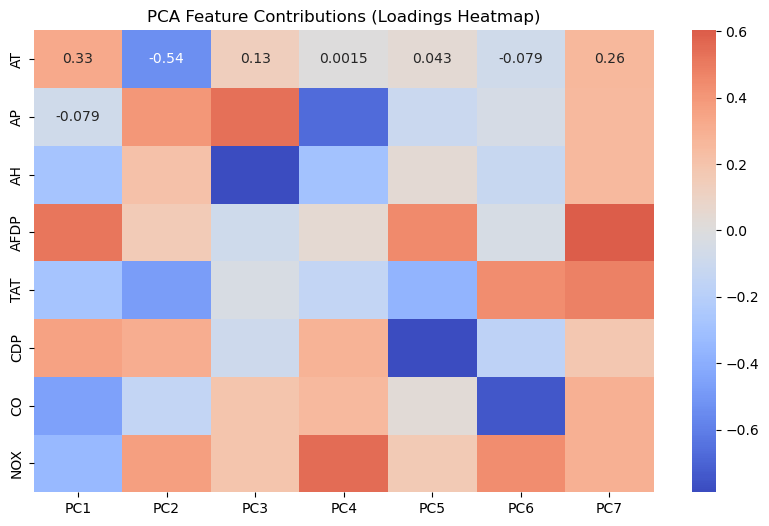

In [123]:
plt.figure(figsize=(10,6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Feature Contributions (Loadings Heatmap)")
plt.show()

PC1: 28.87% variance explained
PC2: 25.76% variance explained
PC3: 12.50% variance explained
PC4: 9.19% variance explained
PC5: 8.15% variance explained
PC6: 7.58% variance explained
PC7: 5.46% variance explained

Cumulative: [28.872107   54.62895622 67.13241983 76.32261427 84.47608098 92.06019604
 97.51790676]


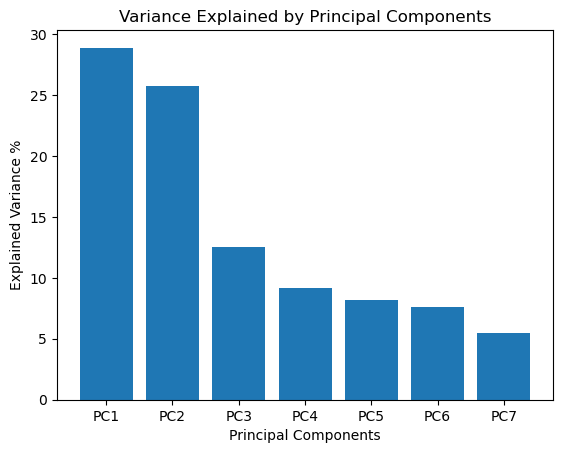

In [124]:
explained_var = pca.explained_variance_ratio_ * 100

for i, var in enumerate(explained_var):
    print(f"PC{i+1}: {var:.2f}% variance explained")

print("\nCumulative:", np.cumsum(explained_var))


import matplotlib.pyplot as plt

plt.figure()

pc_labels = [f"PC{i+1}" for i in range(len(explained_var))]

plt.bar(pc_labels, explained_var)

plt.ylabel("Explained Variance %")
plt.xlabel("Principal Components")
plt.title("Variance Explained by Principal Components")

plt.show()

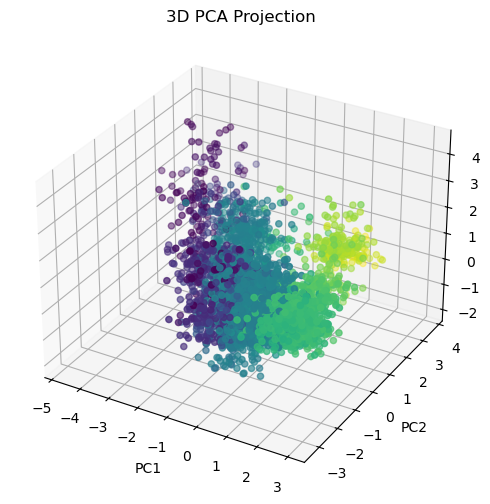

In [125]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test_pca[:,0], X_test_pca[:,1], X_test_pca[:,2], c=y_test, cmap='viridis')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA Projection")
plt.show()


===== Fold 1 =====
MSE: 62.70573351161842
R²: 0.7377288183195925

===== Fold 2 =====
MSE: 154.47294384737972
R²: 0.5187613045996105

===== Fold 3 =====
MSE: 33.97609709595573
R²: 0.7095670060059548

===== Fold 4 =====
MSE: 150.93392551086856
R²: 0.49726348039186163

===== Fold 5 =====
MSE: 48.5987519532668
R²: 0.7398895510078103

===== Fold 6 =====
MSE: 65.87110049023175
R²: 0.729033469075285

===== Fold 7 =====
MSE: 41.405695305425326
R²: 0.6621887278840826

===== Fold 8 =====
MSE: 83.09602509221496
R²: 0.7334814158011329

===== Fold 9 =====
MSE: 105.10123653044009
R²: 0.5855235397892378

===== Fold 10 =====
MSE: 66.82577462929126
R²: 0.6920495017708486


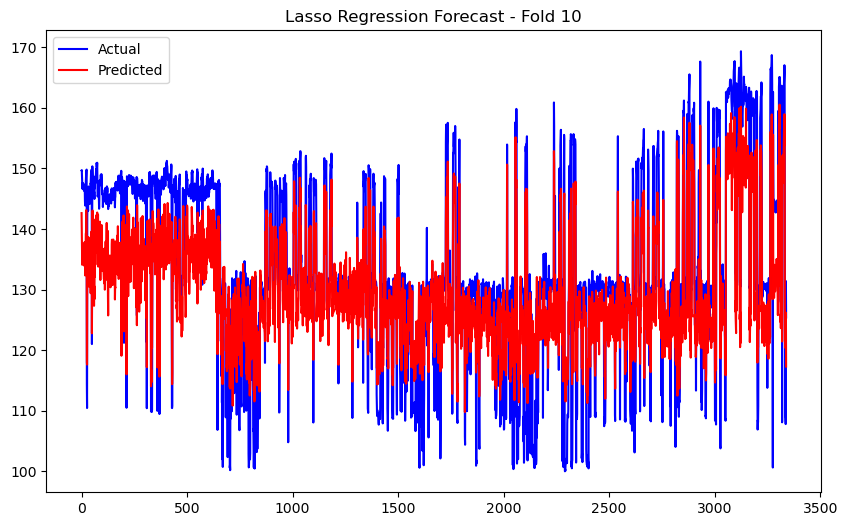


===== FINAL CV RESULTS =====
Average MSE: 81.29872839666926
Average R²: 0.6605486814645417


In [126]:
X = aman_df.drop("TEY", axis=1)
y = aman_df["TEY"]

tscv = TimeSeriesSplit(n_splits=10)

mse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

    lasso_model = Lasso(alpha=0.001)

    lasso_model.fit(X_train_scaled, y_train_scaled.ravel())

    y_pred_scaled = lasso_model.predict(X_test_scaled)

    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
    y_test_actual = scaler_y.inverse_transform(y_test_scaled)

    mse = mean_squared_error(y_test_actual, y_pred)
    r2 = r2_score(y_test_actual, y_pred)

    print("MSE:", mse)
    print("R²:", r2)

    mse_scores.append(mse)
    r2_scores.append(r2)

    if fold == tscv.n_splits:
        plt.figure(figsize=(10,6))
        plt.plot(y_test_actual, label="Actual", color="blue")
        plt.plot(y_pred, label="Predicted", color="red")
        plt.title(f"Lasso Regression Forecast - Fold {fold}")
        plt.legend()
        plt.show()

    fold += 1

print("\n===== FINAL CV RESULTS =====")
print("Average MSE:", np.mean(mse_scores))
print("Average R²:", np.mean(r2_scores))


===== Fold 1 =====
MSE: 52.177429283800166
R²: 0.7817641981211716

===== Fold 2 =====
MSE: 132.0370766123383
R²: 0.5886570883495155

===== Fold 3 =====
MSE: 44.722483974818
R²: 0.6177052095485329

===== Fold 4 =====
MSE: 168.01019743643403
R²: 0.4403851776068277

===== Fold 5 =====
MSE: 47.69888989523505
R²: 0.7447057965807575

===== Fold 6 =====
MSE: 64.67853784747267
R²: 0.7339391797710819

===== Fold 7 =====
MSE: 41.33314970768954
R²: 0.6627805962364133

===== Fold 8 =====
MSE: 76.40013034130166
R²: 0.7549575379980444

===== Fold 9 =====
MSE: 86.18763328255228
R²: 0.6601110858809992

===== Fold 10 =====
MSE: 54.54878383086241
R²: 0.7486250589432708


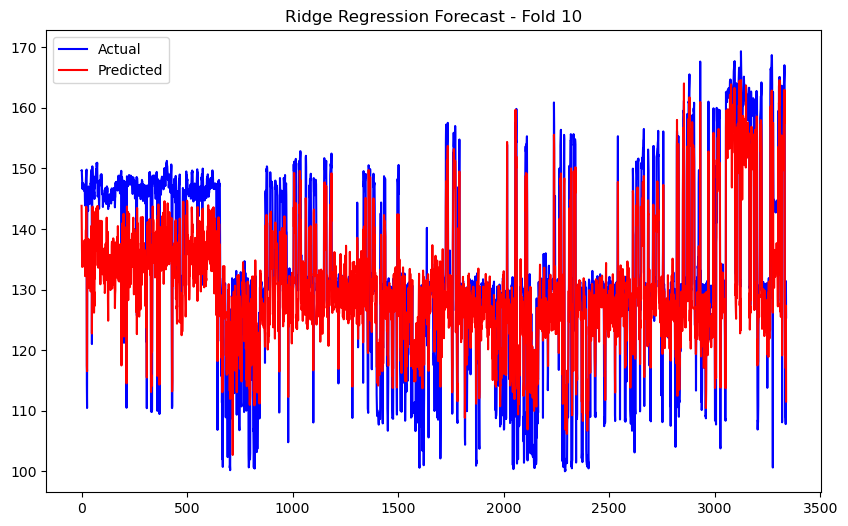


===== FINAL CV RESULTS =====
Average MSE: 76.7794312212504
Average R²: 0.6733630929036615


In [127]:
X = aman_df.drop("TEY", axis=1)
y = aman_df["TEY"]

tscv = TimeSeriesSplit(n_splits=10)

mse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

    ridge_model = Ridge(alpha=1.0)

    ridge_model.fit(X_train_scaled, y_train_scaled)

    y_pred_scaled = ridge_model.predict(X_test_scaled)

    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_test_actual = scaler_y.inverse_transform(y_test_scaled)

    mse = mean_squared_error(y_test_actual, y_pred)
    r2 = r2_score(y_test_actual, y_pred)

    print("MSE:", mse)
    print("R²:", r2)

    mse_scores.append(mse)
    r2_scores.append(r2)

    if fold == tscv.n_splits:
        plt.figure(figsize=(10,6))
        plt.plot(y_test_actual, label="Actual", color="blue")
        plt.plot(y_pred, label="Predicted", color="red")
        plt.title(f"Ridge Regression Forecast - Fold {fold}")
        plt.legend()
        plt.show()

    fold += 1

print("\n===== FINAL CV RESULTS =====")
print("Average MSE:", np.mean(mse_scores))
print("Average R²:", np.mean(r2_scores))

# SECTION 5: Using neural networks

* Time Series Forecasting using LSTM Neural Network with Sequence Modeling
* Time Series Forecasting using GRU Neural Network with Sequence Modeling



Epoch 1/20
827/827 [==============================] - 3s 3ms/step - loss: 0.0211 - val_loss: 0.0152
Epoch 2/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0140 - val_loss: 0.0152
Epoch 3/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0133 - val_loss: 0.0140
Epoch 4/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0131 - val_loss: 0.0139
Epoch 5/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0127 - val_loss: 0.0158
Epoch 6/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0124 - val_loss: 0.0140
Epoch 7/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0122 - val_loss: 0.0135
Epoch 8/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0121 - val_loss: 0.0136
Epoch 9/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0121 - val_loss: 0.0127
Epoch 10/20
827/827 [==============================] - 2s 3ms/step - loss: 0.0119 - val_loss: 0.0140

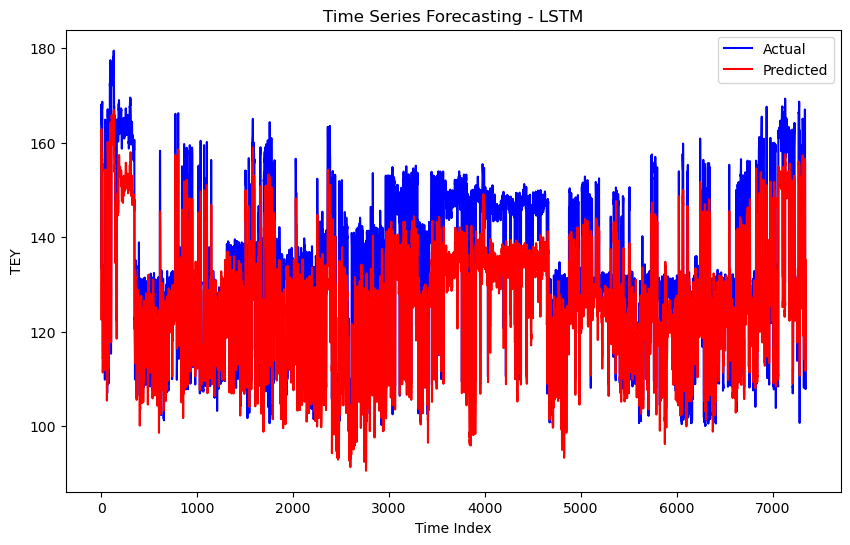

In [128]:
X = aman_df.drop("TEY", axis=1)
y = aman_df["TEY"]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

def create_sequences(X, y, time_steps=50):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

split_index = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

model = Sequential([
    LSTM(50, activation='relu', input_shape=(time_steps, X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

mse = mean_squared_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("Mean Squared Error:", mse)
print("R² Value:", r2)

plt.figure(figsize=(10,6))
plt.plot(y_test_actual, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title("Time Series Forecasting - LSTM")
plt.xlabel("Time Index")
plt.ylabel("TEY")
plt.legend()
plt.show()

Epoch 1/50
827/827 [==============================] - 3s 3ms/step - loss: 0.0238 - val_loss: 0.0162
Epoch 2/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0145 - val_loss: 0.0144
Epoch 3/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0134 - val_loss: 0.0140
Epoch 4/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0130 - val_loss: 0.0137
Epoch 5/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0128 - val_loss: 0.0136
Epoch 6/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0126 - val_loss: 0.0132
Epoch 7/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0125 - val_loss: 0.0139
Epoch 8/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0123 - val_loss: 0.0136
Epoch 9/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0123 - val_loss: 0.0135
Epoch 10/50
827/827 [==============================] - 2s 3ms/step - loss: 0.0123 - val_loss: 0.0136

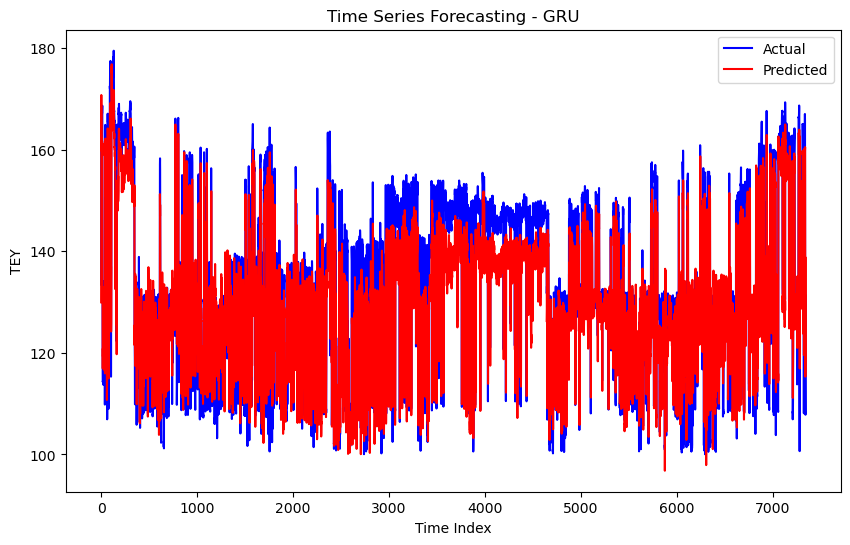

In [129]:
# Features & target
X = aman_df.drop("TEY", axis=1)
y = aman_df["TEY"]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

split_index = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

# ---- GRU Model ----
model = Sequential([
    GRU(20, activation='relu', input_shape=(time_steps, X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1
)

y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

mse = mean_squared_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("Mean Squared Error:", mse)
print("R² Value:", r2)

plt.figure(figsize=(10,6))
plt.plot(y_test_actual, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title("Time Series Forecasting - GRU")
plt.xlabel("Time Index")
plt.ylabel("TEY")
plt.legend()
plt.show()

# SECTION 6: Regression using Boosting tree models

* Time Series Cross-Validation using XGBoost Regression Model
* Time Series Cross-Validation using Lightgbm Regression Model
* Time Series Cross-Validation using XCatBoost Regression Model


===== Fold 1 =====
MSE: 16.37996307742528
R²: 0.9314896416704577

===== Fold 2 =====
MSE: 87.85939791452913
R²: 0.7262864228649262

===== Fold 3 =====
MSE: 34.44384646939107
R²: 0.7055686111761427

===== Fold 4 =====
MSE: 67.33088564850992
R²: 0.7757316984998979

===== Fold 5 =====
MSE: 21.943705110705515
R²: 0.8825528072328586

===== Fold 6 =====
MSE: 31.965636234726446
R²: 0.8685065606181932

===== Fold 7 =====
MSE: 21.896090763672817
R²: 0.8213592062473415

===== Fold 8 =====
MSE: 45.91181826626502
R²: 0.8527444268394129

===== Fold 9 =====
MSE: 72.73491771308831
R²: 0.7131631156526825

===== Fold 10 =====
MSE: 22.17780111570707
R²: 0.8977989414848411


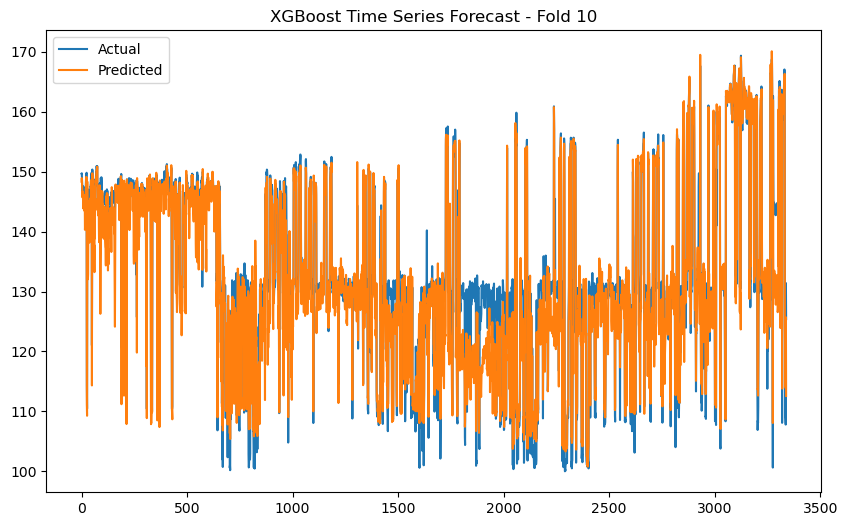


===== FINAL CV RESULTS =====
Average MSE: 42.26440623140205
Average R²: 0.8175201432286754


In [130]:
X = aman_df.drop("TEY", axis=1)
y = aman_df["TEY"]

tscv = TimeSeriesSplit(n_splits=10)

mse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):
    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    xgb_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", mse)
    print("R²:", r2)

    mse_scores.append(mse)
    r2_scores.append(r2)

    if fold == tscv.n_splits:
        plt.figure(figsize=(10,6))
        plt.plot(y_test.values, label='Actual')
        plt.plot(y_pred, label='Predicted')
        plt.title(f"XGBoost Time Series Forecast - Fold {fold}")
        plt.legend()
        plt.show()

    fold += 1

print("\n===== FINAL CV RESULTS =====")
print("Average MSE:", np.mean(mse_scores))
print("Average R²:", np.mean(r2_scores))


===== Fold 1 =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2021
[LightGBM] [Info] Number of data points in the train set: 3343, number of used features: 8
[LightGBM] [Info] Start training from score 141.301810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

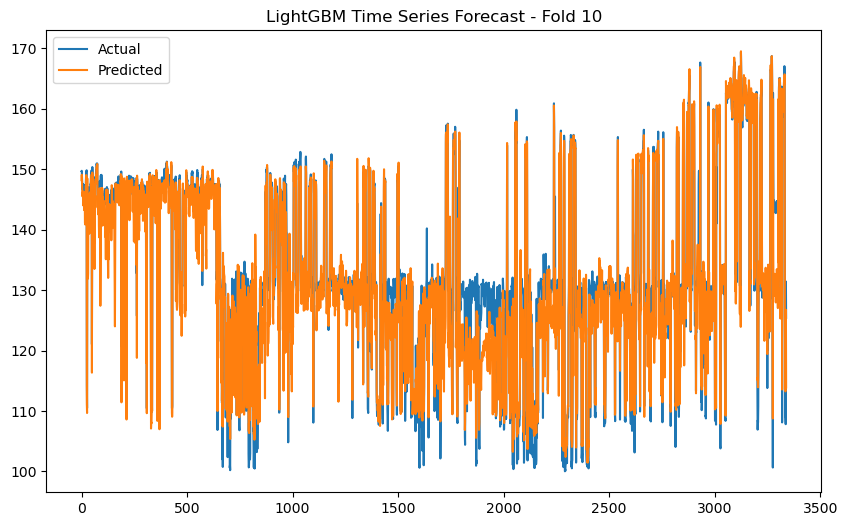


===== FINAL CV RESULTS =====
Average MSE: 42.75996115171834
Average R²: 0.8157847601598123


In [131]:
X = aman_df.drop("TEY", axis=1)
y = aman_df["TEY"]

tscv = TimeSeriesSplit(n_splits=10)

mse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):
    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    lgbm_model = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    lgbm_model.fit(X_train, y_train)

    y_pred = lgbm_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", mse)
    print("R²:", r2)

    mse_scores.append(mse)
    r2_scores.append(r2)

    if fold == tscv.n_splits:
        plt.figure(figsize=(10,6))
        plt.plot(y_test.values, label='Actual')
        plt.plot(y_pred, label='Predicted')
        plt.title(f"LightGBM Time Series Forecast - Fold {fold}")
        plt.legend()
        plt.show()

    fold += 1

print("\n===== FINAL CV RESULTS =====")
print("Average MSE:", np.mean(mse_scores))
print("Average R²:", np.mean(r2_scores))


===== Fold 1 =====
MSE: 13.577741591374885
R²: 0.9432101319560946

===== Fold 2 =====
MSE: 84.30787941815097
R²: 0.7373506784252786

===== Fold 3 =====
MSE: 28.492667796262662
R²: 0.7564402176160693

===== Fold 4 =====
MSE: 101.5139127966311
R²: 0.6618735579927162

===== Fold 5 =====
MSE: 21.501244241184935
R²: 0.8849209481995883

===== Fold 6 =====
MSE: 27.47629018283655
R²: 0.8869738781026121

===== Fold 7 =====
MSE: 22.121455744104278
R²: 0.8195205502323089

===== Fold 8 =====
MSE: 52.467133242769016
R²: 0.8317191941092477

===== Fold 9 =====
MSE: 66.31503595927394
R²: 0.7384805139263173

===== Fold 10 =====
MSE: 23.556743099551806
R²: 0.8914444192468309


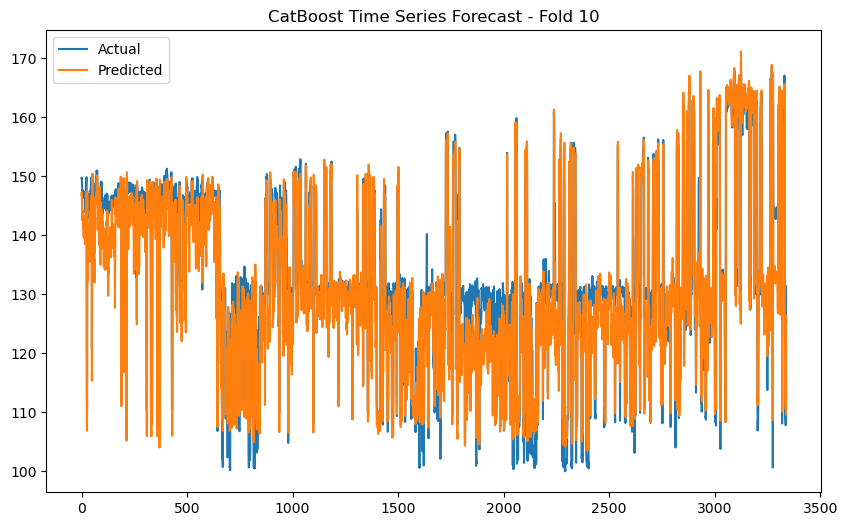


===== FINAL CV RESULTS =====
Average MSE: 44.13301040721401
Average R²: 0.8151934089807064


In [132]:
X = aman_df.drop("TEY", axis=1)
y = aman_df["TEY"]

tscv = TimeSeriesSplit(n_splits=10)

mse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):
    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    cat_model = CatBoostRegressor(
        iterations=200,
        learning_rate=0.05,
        depth=5,
        random_state=42,
        verbose=0
    )

    cat_model.fit(X_train, y_train)

    y_pred = cat_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", mse)
    print("R²:", r2)

    mse_scores.append(mse)
    r2_scores.append(r2)

    if fold == tscv.n_splits:
        plt.figure(figsize=(10,6))
        plt.plot(y_test.values, label='Actual')
        plt.plot(y_pred, label='Predicted')
        plt.title(f"CatBoost Time Series Forecast - Fold {fold}")
        plt.legend()
        plt.show()

    fold += 1

print("\n===== FINAL CV RESULTS =====")
print("Average MSE:", np.mean(mse_scores))
print("Average R²:", np.mean(r2_scores))

In [133]:
split_index = int(len(X) * 0.9)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
cat_model = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=5, verbose=0, random_state=42)

xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
lgbm_pred = lgbm_model.predict(X_test)
cat_pred = cat_model.predict(X_test)

print("\n===== FINAL TEST RESULTS =====")
print("XGBoost R²:", r2_score(y_test, xgb_pred))
print("LightGBM R²:", r2_score(y_test, lgbm_pred))
print("CatBoost R²:", r2_score(y_test, cat_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 33059, number of used features: 8
[LightGBM] [Info] Start training from score 133.417217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

# SECTION 7: Stacking multiple boosting tree models

In [134]:
split_index = int(len(X) * 0.9)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
cat_model = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=5, verbose=0, random_state=42)

xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
lgbm_train_pred = lgbm_model.predict(X_train)
cat_train_pred = cat_model.predict(X_train)

meta_X_train = np.column_stack((xgb_train_pred, lgbm_train_pred, cat_train_pred))

xgb_test_pred = xgb_model.predict(X_test)
lgbm_test_pred = lgbm_model.predict(X_test)
cat_test_pred = cat_model.predict(X_test)

meta_X_test = np.column_stack((xgb_test_pred, lgbm_test_pred, cat_test_pred))

meta_model = LinearRegression()
meta_model.fit(meta_X_train, y_train)

stack_pred = meta_model.predict(meta_X_test)

print("\n===== STACKING RESULTS =====")
print("Stacked R²:", r2_score(y_test, stack_pred))
print("Stacked MSE:", mean_squared_error(y_test, stack_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000298 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 33059, number of used features: 8
[LightGBM] [Info] Start training from score 133.417217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

# SECTION 8: Ensembling multiple boosting tree models

* XGBoost + LightGBM
* XGBoost + Catboost
* LightGBM + Catboost
* Simple ARIMA (Univariate) with TimeSeriesSplit

In [135]:
final_pred = (
    0.6 * xgb_pred +
    0.4 * lgbm_pred 
)

mse = mean_squared_error(y_test, final_pred)
r2 = r2_score(y_test, final_pred)

print("ENSEMBLE RESULTS")
print("MSE:", mse)
print("R2:", r2)

ENSEMBLE RESULTS
MSE: 20.524610662748746
R2: 0.9086133994100268


In [136]:
final_pred = (
    0.6 * xgb_pred +
    0.4 * cat_pred 
)

mse = mean_squared_error(y_test, final_pred)
r2 = r2_score(y_test, final_pred)

print("ENSEMBLE RESULTS")
print("MSE:", mse)
print("R2:", r2)

ENSEMBLE RESULTS
MSE: 20.448208123987687
R2: 0.9089535845861817


In [137]:
final_pred = (
    0.2 * xgb_pred +
    0.2 * cat_pred +
    0.6 * lgbm_pred
)

mse = mean_squared_error(y_test, final_pred)
r2 = r2_score(y_test, final_pred)

print("ENSEMBLE RESULTS")
print("MSE:", mse)
print("R2:", r2)

ENSEMBLE RESULTS
MSE: 19.85682585108273
R2: 0.9115867363890582


In [138]:
final_pred = (
    0.6 * lgbm_pred +
    0.4 * cat_pred 
)

mse = mean_squared_error(y_test, final_pred)
r2 = r2_score(y_test, final_pred)

print("ENSEMBLE RESULTS")
print("MSE:", mse)
print("R2:", r2)

ENSEMBLE RESULTS
MSE: 19.813232459437707
R2: 0.9117808376042328



===== Fold 1 =====
MSE: 259.9410164786137
R²: -0.08722175375590613

===== Fold 2 =====
MSE: 320.82266755457573
R²: 0.0005221746704232588

===== Fold 3 =====
MSE: 156.53923735796562
R²: -0.33812189360708444

===== Fold 4 =====
MSE: 314.31517302949845
R²: -0.0469330577206859

===== Fold 5 =====
MSE: 192.15944890598902
R²: -0.028476627981980585

===== Fold 6 =====
MSE: 383.640906000978
R²: -0.5781404082555954

===== Fold 7 =====
MSE: 328.06289409667664
R²: -1.6765241537752136

===== Fold 8 =====
MSE: 355.23358373401555
R²: -0.13936077798683422

===== Fold 9 =====
MSE: 480.53677033016567
R²: -0.8950412587189096

===== Fold 10 =====
MSE: 483.39595672539787
R²: -1.2276139190505386


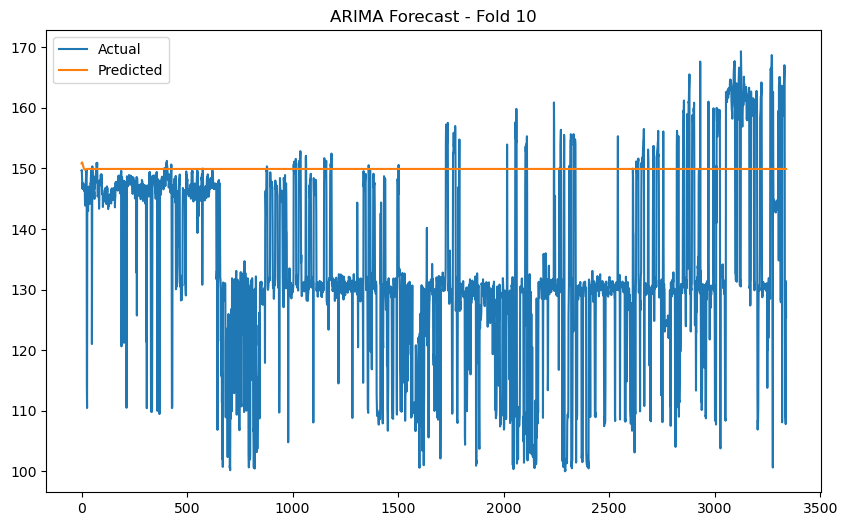


===== FINAL CV RESULTS =====
Average MSE: 327.46476542138765
Average R²: -0.5016911676182325


In [139]:
import warnings
warnings.filterwarnings("ignore")

y = aman_df_filtered["TEY"]

tscv = TimeSeriesSplit(n_splits=10)

mse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(y):
    print(f"\n===== Fold {fold} =====")

    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    try:
        model = ARIMA(y_train, order=(2,1,2))
        model_fit = model.fit()

        y_pred = model_fit.forecast(steps=len(y_test))
        y_pred = np.array(y_pred)
        y_test_arr = np.array(y_test)

        mse = mean_squared_error(y_test_arr, y_pred)
        r2 = r2_score(y_test_arr, y_pred)

        print("MSE:", mse)
        print("R²:", r2)

        mse_scores.append(mse)
        r2_scores.append(r2)

        if fold == tscv.n_splits:
            plt.figure(figsize=(10,6))
            plt.plot(y_test_arr, label='Actual')
            plt.plot(y_pred, label='Predicted')
            plt.title(f"ARIMA Forecast - Fold {fold}")
            plt.legend()
            plt.show()

    except Exception:
        print("ARIMA failed on this fold")

    fold += 1

print("\n===== FINAL CV RESULTS =====")
print("Average MSE:", np.mean(mse_scores))
print("Average R²:", np.mean(r2_scores))

# SECTION 9: Training on entire datasets

In [140]:
lgbm_model_final = LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
cat_model_final = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=5, verbose=0, random_state=42)

lgbm_model_final.fit(X, y)
cat_model_final.fit(X, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 36733, number of used features: 8
[LightGBM] [Info] Start training from score 133.506404
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

CatBoostRegressor(depth=5, iterations=200, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)